# 🏦 NEXUM Financial Ecosystem — Offshore Intelligence System (OIS)
### Sistema Automatizado de Scoring e Priorização de Carteiras Internacionais

---

| Campo | Detalhe |
|---|---|
| **Empresa** | NEXUM Financial Ecosystem (Grupo Multi-Vertical) |
| **Projeto** | Offshore Intelligence System — OIS v1.0 |
| **Área Demandante** | Especialista de Mercado Internacional |
| **Metodologia** | CRISP-DM |
| **Filosofia** | *"Nunca comece pelo código. Comece pela pergunta do negócio."* |

---

## 🧭 Estrutura do Projeto

```
Fase 0 ── Setup e Organização Inicial
Fase 1 ── Business Understanding   → Dor, tradução analítica, metas
Fase 2 ── Data Understanding (EDA) → 40k clientes, auditoria, correlações, hipóteses
Fase 3 ── Feature Engineering      → Faixas de threshold, score ponderado
Fase 4 ── Modeling                 → Sistema de regras + K-Means Clustering
Fase 5 ── Evaluation               → ROI, distribuição do score, validação
Fase 6 ── Deployment               → Output acionável ranqueado + exportação
```

---

> **Contexto da Dor:** O Especialista de Mercado Internacional da NEXUM analisa manualmente ~3.000 clientes
> com conta global ativa para identificar gaps de alocação e repassa ações para os assessores.
> Esse processo consome horas semanais, é subjetivo e não escala.
>
> **Solução proposta:** Um sistema de inteligência de carteira que processa toda a base automaticamente,
> gera um **score ponderado de urgência** por cliente e entrega uma lista ranqueada com o motivo de ação —
> transformando dias de trabalho braçal em segundos de processamento automatizado.

In [1]:
# ============================================================
# FASE 0: SETUP E ORGANIZAÇÃO INICIAL
# ============================================================
# POR QUÊ: Agrupar imports por finalidade facilita manutenção,
#          melhora a leitura e deixa claro quais capacidades usamos.
# COMO:    Blocos lógicos — Dados | Visualização | ML | Utilitários.
# O QUÊ:   Ambiente configurado, seed fixada para reprodutibilidade.

# ── Manipulação e Análise ────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualização ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning e Estatística ───────────────────────────
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ── Utilitários ──────────────────────────────────────────────
import warnings
import joblib
import json
import os
warnings.filterwarnings('ignore')

# ── Configurações Globais ────────────────────────────────────
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
SEED = 42
np.random.seed(SEED)

# Benchmark cambial — clientes com dólar médio > R$5,00 são candidatos a contato
DOLAR_BENCHMARK = 5.00

# Identidade visual NEXUM — Azul naval + Dourado + Verde esmeralda
NEXUM_PALETTE = ['#1B3A6B', '#2E86AB', '#44BBA4', '#F18F01', '#E9C46A', '#C73E1D', '#6C757D']
PRIORITY_COLORS = {
    'CRÍTICO':  '#C73E1D',
    'ALTO':     '#F18F01',
    'MODERADO': '#E9C46A',
    'BAIXO':    '#44BBA4',
    'SEM GAP':  '#6C757D',
}
SEG_COLORS = {
    'Qualificado': '#6C757D',
    'Investidor':  '#2E86AB',
    'Alta Renda':  '#F18F01',
    'Wealth':      '#1B3A6B',
}
seg_order = ['Qualificado', 'Investidor', 'Alta Renda', 'Wealth']
sns.set_theme(style='whitegrid', palette=NEXUM_PALETTE)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

print('✅ [Fase 0] Setup concluído com sucesso!')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__} | Seed: {SEED}')
print(f'   Benchmark Dólar: R${DOLAR_BENCHMARK:.2f}')

✅ [Fase 0] Setup concluído com sucesso!
   NumPy 2.0.2 | Pandas 2.2.2 | Seed: 42
   Benchmark Dólar: R$5.00


---
## 📋 Fase 1: Business Understanding (Entendimento do Negócio)


### 1.1 A Dor de Negócio

O **Especialista de Mercado Internacional** da NEXUM é responsável por identificar oportunidades
de alocação offshore na base de clientes e delegar ações para os assessores. Hoje, esse processo é **100% manual**:

1. Abre a base de clientes
2. Filtra e analisa cliente a cliente
3. Identifica gaps com base em critérios qualitativos
4. Liga ou envia e-mail para os assessores com recomendações
5. Repete o processo semana após semana

**Armadilhas identificadas previamente:**
- ⚠️ **Sem variável-alvo histórica:** não há dados de conversão para treinar modelo supervisionado clássico.
- ⚠️ **Processo subjetivo:** critérios variam conforme a experiência do especialista.
- ⚠️ **Não escala:** com 3.000 clientes ativos, a análise manual perde oportunidades sistematicamente.

### 1.2 Tradução Analítica

| Pergunta de Negócio | Pergunta Analítica |
|---|---|
| Quem está mais desprotegido offshore? | Score de gap por cliente (0–100) |
| Qual a urgência de contato? | Ranking de prioridade (CRÍTICO/ALTO/MODERADO/BAIXO) |
| Por que devo ligar para esse cliente? | Motivo de ação por critério dominante |
| Quais segmentos têm mais oportunidade? | Análise por cluster e segmento |

### 1.3 Por que NÃO usar um modelo supervisionado clássico?

> Um modelo como XGBoost precisa de uma **variável-alvo** — "o cliente converteu? Sim/Não".
> Esse dado **não existe** na empresa hoje. Não há histórico de conversões offshore.
>
> **Nossa abordagem:** Sistema de scoring ponderado (knowledge-driven) + K-Means Clustering
> para descobrir perfis comportamentais latentes. Solução robusta, interpretável e acionável.

In [2]:
# ============================================================
# FASE 1: CRITÉRIOS DE GAP E PESOS (Economist-Driven)
# ============================================================
# POR QUÊ: Documentar os critérios como artefato de código garante
#          transparência. O especialista pode auditar e ajustar os pesos.
# COMO:    Lista estruturada com nome, peso e justificativa macroeconômica.
# O QUÊ:   10 critérios somando 100% dos pesos.

CRITERIOS = [
    {'nome': 'sc_concentr_br',  'peso': 0.20, 'descricao': 'Concentração no Brasil (risco país)',
     'racional': 'Risco fiscal/político elevado. Carteiras >85% BR têm risco sistêmico não compensado.'},
    {'nome': 'sc_offshore',     'peso': 0.18, 'descricao': 'Baixa alocação offshore',
     'racional': 'Gap estrutural. Clientes com PL alto e offshore baixo têm carteira mal construída.'},
    {'nome': 'sc_cdi',          'peso': 0.15, 'descricao': 'Concentração excessiva em CDI',
     'racional': 'Com ciclo de queda Selic, retorno real do CDI comprime. Hora de diversificar.'},
    {'nome': 'sc_caixa_usd',    'peso': 0.13, 'descricao': 'Caixa parado na conta internacional',
     'racional': 'Custo de oportunidade direto e mensurável. USD parado perde para T-Bills e RF global.'},
    {'nome': 'sc_remessa',      'peso': 0.10, 'descricao': 'Inatividade de remessas (>30 dias)',
     'racional': 'Sinal de desengajamento com a plataforma internacional. Risco de churn silencioso.'},
    {'nome': 'sc_dolar',        'peso': 0.09, 'descricao': 'Dólar médio acima de R$5,00',
     'racional': 'Argumento de venda tangível. Cliente que comprou caro tem incentivo a reforçar posição.'},
    {'nome': 'sc_perfil_rf',    'peso': 0.07, 'descricao': 'Perfil conservador sem RF global',
     'racional': 'Mismatch perfil x carteira. T-Bills e bonds IG são equivalentes ao CDI, mas em USD.'},
    {'nome': 'sc_bdr',          'peso': 0.04, 'descricao': 'Exposição relevante em BDR/Feeder',
     'racional': 'Duplicação de risco BR com custo mais alto. Melhor ter o ativo diretamente offshore.'},
    {'nome': 'sc_perda_br',     'peso': 0.02, 'descricao': 'Perda em ações brasileiras',
     'racional': 'Sinal emocional e argumento de diversificação. Abordagem requer sensibilidade.'},
    {'nome': 'sc_gastos_dolar', 'peso': 0.02, 'descricao': 'Gastos recorrentes em dólar (viagens)',
     'racional': 'Oportunidade de cross-sell para cartão global. Hedging natural de gastos.'},
]

PESOS = {c['nome']: c['peso'] for c in CRITERIOS}
assert abs(sum(PESOS.values()) - 1.0) < 0.001, 'ERRO: pesos não somam 100%'

NOMES_CRITERIOS = {c['nome']: c['descricao'] for c in CRITERIOS}

print('📊 Critérios de Gap — Offshore Intelligence System')
print('=' * 60)
for c in CRITERIOS:
    barra = '█' * int(c['peso'] * 100)
    print(f"  {c['peso']*100:4.0f}%  {barra:20s}  {c['descricao']}")
print('=' * 60)
print(f"  TOTAL: {sum(PESOS.values())*100:.0f}% ✅")

📊 Critérios de Gap — Offshore Intelligence System
    20%  ████████████████████  Concentração no Brasil (risco país)
    18%  ██████████████████    Baixa alocação offshore
    15%  ███████████████       Concentração excessiva em CDI
    13%  █████████████         Caixa parado na conta internacional
    10%  ██████████            Inatividade de remessas (>30 dias)
     9%  █████████             Dólar médio acima de R$5,00
     7%  ███████               Perfil conservador sem RF global
     4%  ████                  Exposição relevante em BDR/Feeder
     2%  ██                    Perda em ações brasileiras
     2%  ██                    Gastos recorrentes em dólar (viagens)
  TOTAL: 100% ✅


---
## 🔍 Fase 2: Data Understanding (Entendimento dos Dados)
*Dados sujos geram modelos ruins. "Garbage in, garbage out." Explore profundamente.*

### 2.1 Geração da Base Sintética

Como não temos acesso à uma base real de empresa, geramos dados sintéticos calibrados com:
- **Distribuição log-normal** para Patrimônio Líquido (a riqueza segue a Lei de Pareto)
- **Distribuições normais truncadas** para percentuais de alocação
- **Probabilidades condicionadas** ao segmento e perfil de risco
- **Correlações realistas** entre variáveis (ex: mais offshore → menos CDI)

**Premissas validadas com o negócio:**

| Variável | Valor |
|---|---|
| Total de clientes | 40.000 |
| Clientes com conta global ativa (acima de US$ 10k) | 3.000 (7,5%) |

| Variável | Valor |
|---|---|
| Benchmark de dólar | R$ 5,00 |
| Segmentos | Wealth / Alta Renda / Investidor / Qualificado |

In [3]:
# ============================================================
# FASE 2.1: GERAÇÃO DA BASE SINTÉTICA NEXUM ECOSYSTEM
# ============================================================
# POR QUÊ: Base realista e diversa é essencial para que a EDA
#          produza insights representativos do mercado real.
# COMO:    Parâmetros calibrados por segmento; distribuições
#          estatísticas adequadas a cada variável.
# O QUÊ:   df_total (40k) e df_global (~3.000 ativos offshore).

def gerar_base_nexum(n_total=40_000, seed=42):
    rng = np.random.default_rng(seed)

    PARAMS = {
        'Qualificado': {
            'n_total': 26_000, 'n_ativo': 450,
            'pl_mu': np.log(200_000), 'pl_sigma': 0.55,
            'pl_min': 100_000, 'pl_max': 500_000,
            'perfil': ['Conservador','Moderado','Arrojado','Sofisticado'],
            'perfil_p': [0.45, 0.40, 0.13, 0.02],
            'offshore_base': 0.06, 'offshore_std': 0.06,
            'cdi_base': 0.65, 'cdi_std': 0.15,
            'acoes_br_base': 0.12, 'bdr_base': 0.03,
            'saldo_usd_mu': np.log(15_000), 'saldo_usd_sigma': 0.50,
            'saldo_usd_min': 10_000, 'saldo_usd_max': 150_000,
            'prob_gastos_dolar': 0.15,
        },
        'Investidor': {
            'n_total': 10_000, 'n_ativo': 1_350,
            'pl_mu': np.log(1_500_000), 'pl_sigma': 0.60,
            'pl_min': 500_000, 'pl_max': 5_000_000,
            'perfil': ['Conservador','Moderado','Arrojado','Sofisticado'],
            'perfil_p': [0.25, 0.45, 0.25, 0.05],
            'offshore_base': 0.10, 'offshore_std': 0.08,
            'cdi_base': 0.52, 'cdi_std': 0.18,
            'acoes_br_base': 0.20, 'bdr_base': 0.06,
            'saldo_usd_mu': np.log(35_000), 'saldo_usd_sigma': 0.70,
            'saldo_usd_min': 10_000, 'saldo_usd_max': 500_000,
            'prob_gastos_dolar': 0.30,
        },
        'Alta Renda': {
            'n_total': 3_200, 'n_ativo': 960,
            'pl_mu': np.log(10_000_000), 'pl_sigma': 0.65,
            'pl_min': 5_000_000, 'pl_max': 30_000_000,
            'perfil': ['Conservador','Moderado','Arrojado','Sofisticado'],
            'perfil_p': [0.15, 0.35, 0.35, 0.15],
            'offshore_base': 0.15, 'offshore_std': 0.10,
            'cdi_base': 0.38, 'cdi_std': 0.15,
            'acoes_br_base': 0.22, 'bdr_base': 0.08,
            'saldo_usd_mu': np.log(100_000), 'saldo_usd_sigma': 0.80,
            'saldo_usd_min': 10_000, 'saldo_usd_max': 2_000_000,
            'prob_gastos_dolar': 0.50,
        },
        'Wealth': {
            'n_total': 800, 'n_ativo': 240,
            'pl_mu': np.log(80_000_000), 'pl_sigma': 0.70,
            'pl_min': 30_000_000, 'pl_max': 500_000_000,
            'perfil': ['Conservador','Moderado','Arrojado','Sofisticado'],
            'perfil_p': [0.05, 0.20, 0.35, 0.40],
            'offshore_base': 0.25, 'offshore_std': 0.12,
            'cdi_base': 0.22, 'cdi_std': 0.12,
            'acoes_br_base': 0.18, 'bdr_base': 0.05,
            'saldo_usd_mu': np.log(400_000), 'saldo_usd_sigma': 0.90,
            'saldo_usd_min': 10_000, 'saldo_usd_max': 15_000_000,
            'prob_gastos_dolar': 0.65,
        },
    }

    fator_perfil = {'Conservador': 0.65, 'Moderado': 0.90, 'Arrojado': 1.10, 'Sofisticado': 1.35}
    rows_total, rows_global = [], []
    id_global = 1

    for seg, p in PARAMS.items():
        n = p['n_total']
        pl     = np.clip(rng.lognormal(p['pl_mu'], p['pl_sigma'], n), p['pl_min'], p['pl_max'])
        perfil = rng.choice(p['perfil'], size=n, p=p['perfil_p'])
        tipo   = rng.choice(['PF', 'PJ'], size=n, p=[0.85, 0.15])
        idx_ativos = rng.choice(n, size=p['n_ativo'], replace=False)
        conta_flag = np.zeros(n, dtype=bool)
        conta_flag[idx_ativos] = True

        for i in range(n):
            rows_total.append({
                'segmento':        seg,
                'pl_brl':          round(float(pl[i]), 2),
                'perfil_risco':    perfil[i],
                'tipo_cliente':    tipo[i],
                'tem_conta_global': bool(conta_flag[i]),
            })

        for idx in idx_ativos:
            dolar_medio  = float(np.clip(rng.lognormal(np.log(5.20), 0.18), 3.50, 8.00))
            adj          = fator_perfil.get(perfil[idx], 1.0)
            pct_offshore = float(np.clip(rng.normal(p['offshore_base'] * adj, p['offshore_std']), 0.0, 0.70))

            if perfil[idx] in ['Conservador', 'Moderado']:
                rf_ratio = float(rng.beta(3, 2))
            else:
                rf_ratio = float(rng.beta(2, 3))
            pct_rf_global    = round(rf_ratio * pct_offshore, 4)
            pct_acoes_global = round((1 - rf_ratio) * pct_offshore, 4)

            pct_brl_total = round(1.0 - pct_offshore, 4)
            cdi_corr  = p['cdi_base'] * (1.0 - pct_offshore * 0.5)
            cdi_raw   = float(np.clip(rng.normal(cdi_corr, p['cdi_std']), 0.05, 0.95))
            acoes_raw = float(np.clip(rng.normal(p['acoes_br_base'], 0.08), 0.0, 0.50))
            bdr_raw   = float(np.clip(rng.normal(p['bdr_base'], 0.04), 0.0, 0.25))
            caixa_raw = float(rng.beta(1.2, 6))
            soma_brl  = cdi_raw + acoes_raw + bdr_raw + caixa_raw
            pct_cdi       = round(cdi_raw   / soma_brl * pct_brl_total, 4)
            pct_acoes_br  = round(acoes_raw / soma_brl * pct_brl_total, 4)
            pct_bdr       = round(bdr_raw   / soma_brl * pct_brl_total, 4)
            pct_caixa_brl = round(caixa_raw / soma_brl * pct_brl_total, 4)

            saldo_usd = float(np.clip(
                rng.lognormal(p['saldo_usd_mu'], p['saldo_usd_sigma']),
                p['saldo_usd_min'], p['saldo_usd_max']
            ))
            pct_caixa_global = float(rng.beta(1.5, 4))
            caixa_parado_usd = round(saldo_usd * pct_caixa_global, 2)
            dias_rem         = int(np.clip(rng.lognormal(3.2, 0.85), 0, 730))
            tem_gastos       = bool(rng.random() < p['prob_gastos_dolar'])
            var_br           = float(np.clip(rng.normal(-0.06, 0.22), -0.70, 0.70))

            rows_global.append({
                'id_cliente':             f'G{str(id_global).zfill(4)}',
                'segmento':               seg,
                'pl_brl':                 round(float(pl[idx]), 2),
                'perfil_risco':           perfil[idx],
                'tipo_cliente':           tipo[idx],
                'pct_offshore':           round(pct_offshore, 4),
                'pct_rf_global':          pct_rf_global,
                'pct_acoes_global':       pct_acoes_global,
                'pct_cdi':                pct_cdi,
                'pct_acoes_br':           pct_acoes_br,
                'pct_bdr':                pct_bdr,
                'pct_caixa_brl':          pct_caixa_brl,
                'saldo_conta_global_usd': round(saldo_usd, 2),
                'caixa_parado_usd':       round(caixa_parado_usd, 2),
                'dias_sem_remessa':       dias_rem,
                'dolar_medio_compra':     round(dolar_medio, 4),
                'tem_gastos_dolar':       tem_gastos,
                'variacao_acoes_br_pct':  round(var_br, 4),
            })
            id_global += 1

    df_total  = pd.DataFrame(rows_total)
    df_total.insert(0, 'id_cliente', [f'C{str(i).zfill(5)}' for i in range(1, len(df_total) + 1)])
    df_global = pd.DataFrame(rows_global)
    return df_total, df_global


df_total, df_global = gerar_base_nexum(n_total=40_000, seed=SEED)
print(f'✅ Base Total   : {len(df_total):,} clientes')
print(f'✅ Base Offshore: {len(df_global):,} clientes ativos ({len(df_global)/len(df_total)*100:.1f}% da base)')
print()
resumo = df_total.groupby('segmento').agg(
    total          = ('id_cliente', 'count'),
    conta_ativa    = ('tem_conta_global', 'sum'),
    taxa_ativacao  = ('tem_conta_global', lambda x: f'{x.mean()*100:.1f}%'),
    pl_mediano_brl = ('pl_brl', 'median'),
).reindex(seg_order)
print('Distribuição por Segmento:')
print(resumo.to_string())

✅ Base Total   : 40,000 clientes
✅ Base Offshore: 3,000 clientes ativos (7.5% da base)

Distribuição por Segmento:
             total  conta_ativa taxa_ativacao  pl_mediano_brl
segmento                                                     
Qualificado  26000          450          1.7%      200,340.95
Investidor   10000         1350         13.5%    1,477,808.73
Alta Renda    3200          960         30.0%    9,892,054.35
Wealth         800          240         30.0%   85,421,410.75


In [4]:
# ============================================================
# FASE 2.2: AUDITORIA DE QUALIDADE DOS DADOS
# ============================================================
# POR QUÊ: Antes de qualquer análise garantimos integridade da base.
# COMO:    Verificar nulos, duplicatas, tipos e estatísticas descritivas.

print('━' * 60)
print('AUDITORIA — BASE OFFSHORE ATIVA (df_global)')
print('━' * 60)
print(f'  Shape         : {df_global.shape[0]:,} linhas × {df_global.shape[1]} colunas')
print(f'  Duplicatas    : {df_global.duplicated().sum()}')
print(f'  Valores nulos : {df_global.isnull().sum().sum()}')
print()
cols_desc = ['pl_brl','pct_offshore','pct_cdi','saldo_conta_global_usd',
             'caixa_parado_usd','dias_sem_remessa','dolar_medio_compra']
print('Estatísticas Descritivas — Variáveis Numéricas Chave:')
print(df_global[cols_desc].describe().round(4).to_string())
print()
print('Perfil de Risco (base offshore):')
print(df_global['perfil_risco'].value_counts().to_string())
print()
print('Tipo de Cliente (PF/PJ):')
print(df_global['tipo_cliente'].value_counts().to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AUDITORIA — BASE OFFSHORE ATIVA (df_global)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Shape         : 3,000 linhas × 18 colunas
  Duplicatas    : 0
  Valores nulos : 0

Estatísticas Descritivas — Variáveis Numéricas Chave:
              pl_brl  pct_offshore  pct_cdi  saldo_conta_global_usd  caixa_parado_usd  dias_sem_remessa  dolar_medio_compra
count       3,000.00      3,000.00 3,000.00                3,000.00          3,000.00          3,000.00            3,000.00
mean   13,253,090.21          0.12     0.45              109,069.25         29,694.95             34.68                5.30
std    36,262,695.96          0.10     0.17              208,965.55         77,344.41             36.33                0.92
min       100,000.00          0.00     0.04               10,000.00             22.51              0.00                3.50
25%       955,244.21          0.04     0.34               22,504.42        

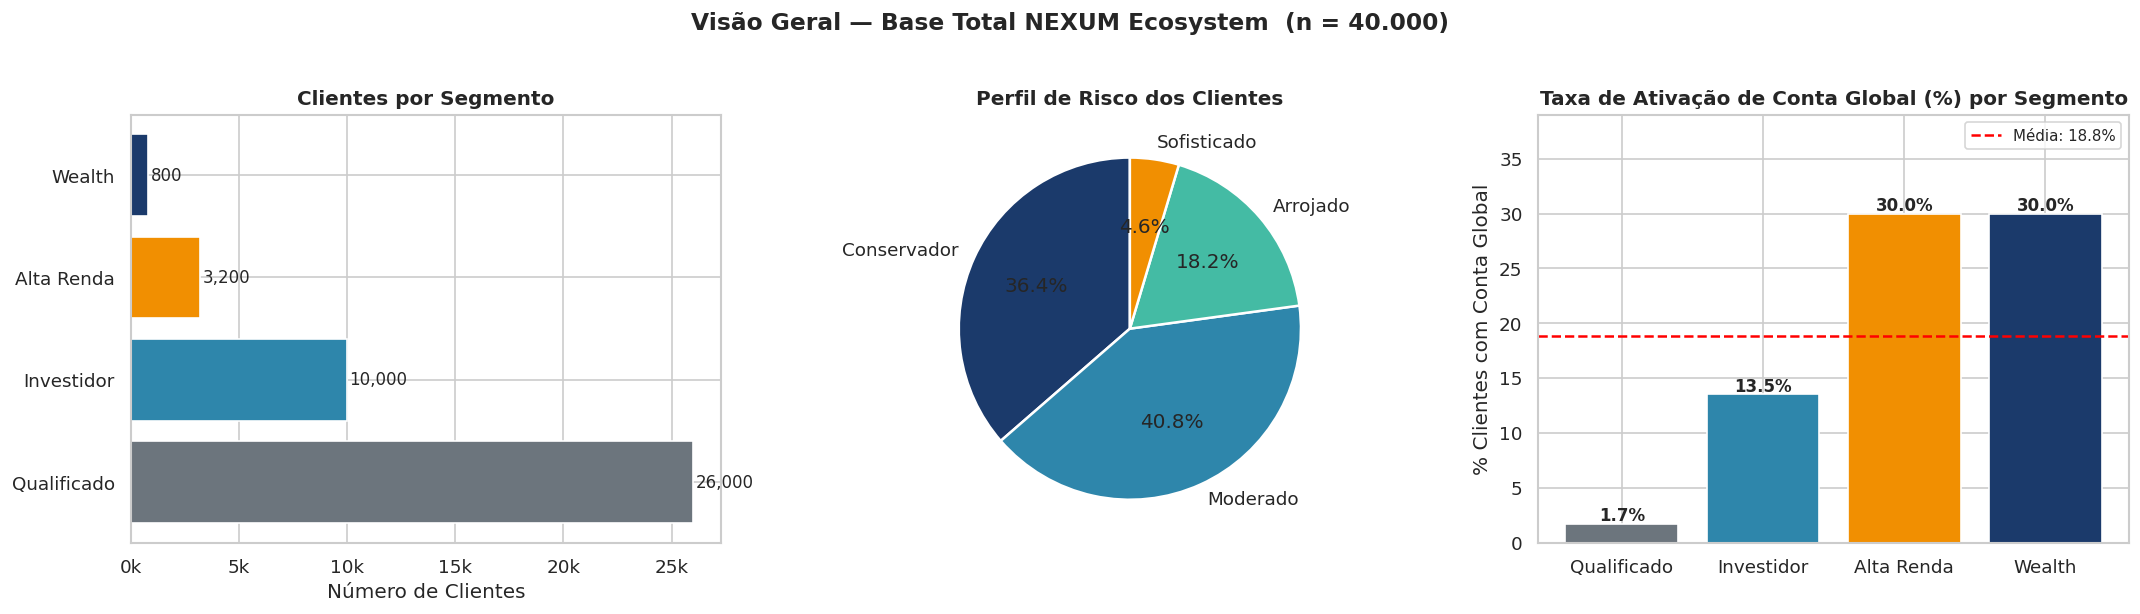

💡 INSIGHT: A taxa de ativação cresce exponencialmente com o PL.
   Wealth: 30.0% | Alta Renda: 30.0% | Investidor: 13.5% | Qualificado: 1.7%
   → O segmento Investidor tem ENORME potencial de ativação (módulo de propensão).


In [5]:
# ============================================================
# FASE 2.3: EDA — VISÃO GERAL DA BASE TOTAL (40.000 CLIENTES)
# ============================================================
# POR QUÊ: Entender a composição da base total revela onde estão
#          as maiores oportunidades de ativação e cross-sell.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Visão Geral — Base Total NEXUM Ecosystem  (n = 40.000)',
             fontsize=14, fontweight='bold', y=1.02)

# ── Clientes por Segmento ─────────────────────────────────────
ax = axes[0]
seg_counts = df_total['segmento'].value_counts().reindex(seg_order)
bars = ax.barh(seg_counts.index, seg_counts.values,
               color=[SEG_COLORS[s] for s in seg_counts.index])
ax.set_title('Clientes por Segmento', fontweight='bold')
ax.set_xlabel('Número de Clientes')
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# ── Perfil de Risco ───────────────────────────────────────────
ax = axes[1]
perfil_order = ['Conservador','Moderado','Arrojado','Sofisticado']
perfil_counts = df_total['perfil_risco'].value_counts().reindex(perfil_order)
ax.pie(perfil_counts.values, labels=perfil_counts.index, autopct='%1.1f%%',
       colors=NEXUM_PALETTE[:4], startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Perfil de Risco dos Clientes', fontweight='bold')

# ── Taxa de Ativação Conta Global ────────────────────────────
ax = axes[2]
ativacao = df_total.groupby('segmento')['tem_conta_global'].mean().reindex(seg_order) * 100
bars = ax.bar(ativacao.index, ativacao.values, color=[SEG_COLORS[s] for s in ativacao.index])
ax.set_title('Taxa de Ativação de Conta Global (%) por Segmento', fontweight='bold')
ax.set_ylabel('% Clientes com Conta Global')
ax.set_ylim(0, max(ativacao.values) * 1.30)
for bar, val in zip(bars, ativacao.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax.axhline(ativacao.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Média: {ativacao.mean():.1f}%')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../images/../images/eda_base_total.png', bbox_inches='tight', dpi=150)
plt.show()

print('💡 INSIGHT: A taxa de ativação cresce exponencialmente com o PL.')
print(f'   Wealth: {ativacao["Wealth"]:.1f}% | Alta Renda: {ativacao["Alta Renda"]:.1f}% | '
      f'Investidor: {ativacao["Investidor"]:.1f}% | Qualificado: {ativacao["Qualificado"]:.1f}%')
print('   → O segmento Investidor tem ENORME potencial de ativação (módulo de propensão).')

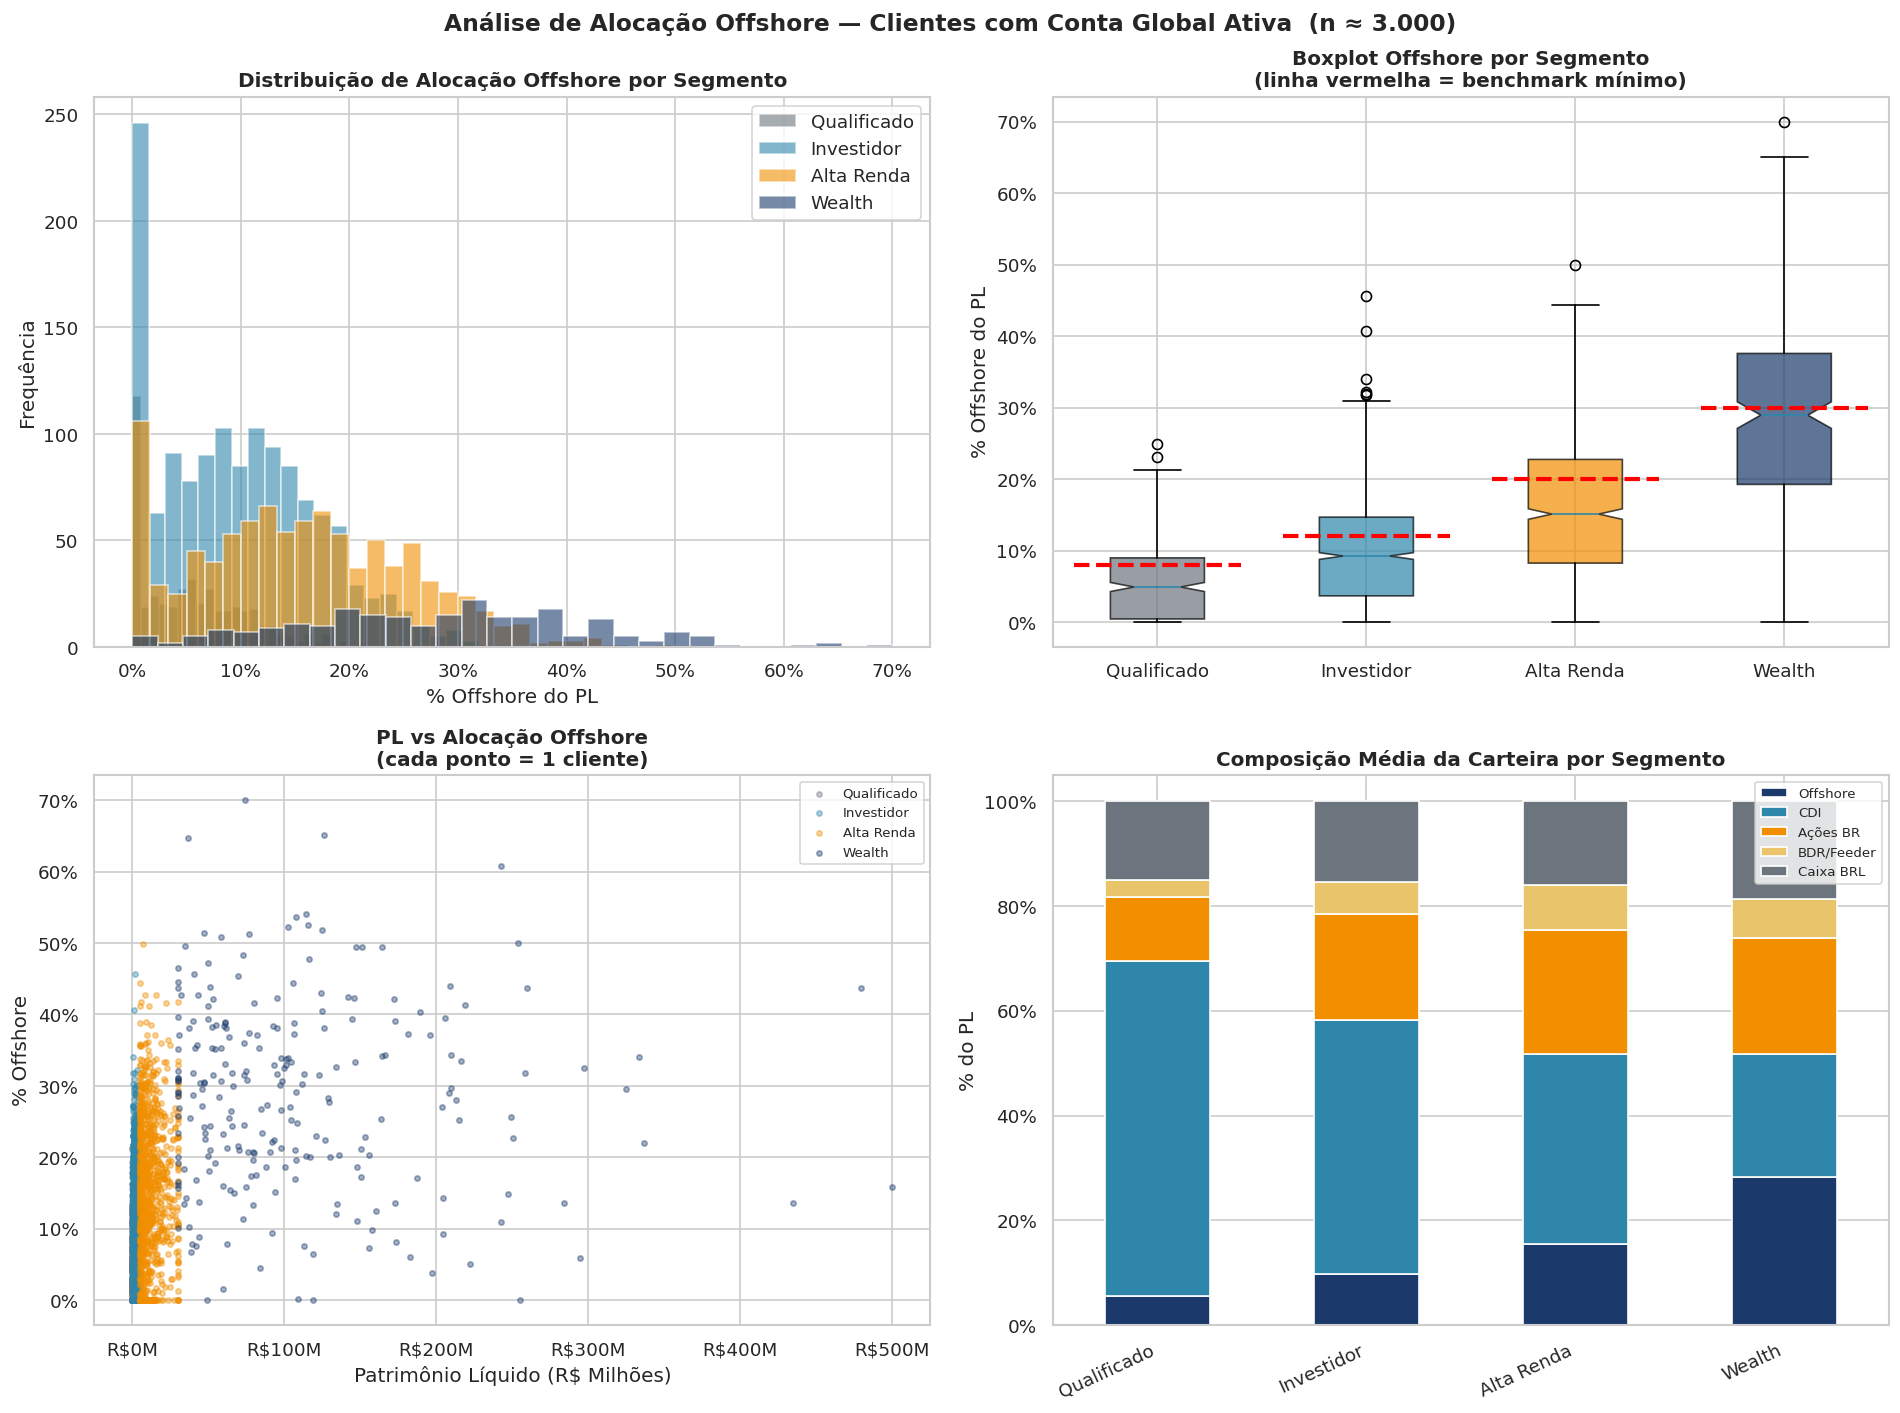

💡 INSIGHT 1: Wealth tem maior mediana offshore, mas há clientes com PL > R$30M e <10% offshore → CRÍTICO.
💡 INSIGHT 2: CDI domina em todos os segmentos. Com Selic em queda, esse gap é urgente.
💡 INSIGHT 3: Alta dispersão no scatter PL x Offshore revela enorme oportunidade latente.


In [7]:
# ============================================================
# FASE 2.4: EDA — ANÁLISE DE ALOCAÇÃO OFFSHORE
# ============================================================
# POR QUÊ: O gap de alocação offshore tem MAIOR PESO no scoring (18%).
#          Precisamos entender a distribuição real por segmento.
# COMO:    Histogramas sobrepostos, boxplots com benchmark e scatter PL x Offshore.

OFFSHORE_BENCHMARK = {'Qualificado': 0.08, 'Investidor': 0.12, 'Alta Renda': 0.20, 'Wealth': 0.30}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análise de Alocação Offshore — Clientes com Conta Global Ativa  (n ≈ 3.000)',
             fontsize=14, fontweight='bold')

# ── Distribuição % offshore por segmento ─────────────────────
ax = axes[0, 0]
for seg in seg_order:
    dados = df_global[df_global['segmento'] == seg]['pct_offshore'] * 100
    ax.hist(dados, bins=30, alpha=0.6, label=seg, color=SEG_COLORS[seg], edgecolor='white')
ax.set_title('Distribuição de Alocação Offshore por Segmento', fontweight='bold')
ax.set_xlabel('% Offshore do PL')
ax.set_ylabel('Frequência')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# ── Boxplot % offshore com benchmarks ────────────────────────
ax = axes[0, 1]
data_box = [df_global[df_global['segmento'] == s]['pct_offshore'].values * 100 for s in seg_order]
bp = ax.boxplot(data_box, labels=seg_order, patch_artist=True, notch=True)
for patch, seg in zip(bp['boxes'], seg_order):
    patch.set_facecolor(SEG_COLORS[seg])
    patch.set_alpha(0.7)
for i, seg in enumerate(seg_order, 1):
    bench = OFFSHORE_BENCHMARK[seg] * 100
    ax.hlines(bench, i - 0.4, i + 0.4, colors='red', linewidth=2.5, linestyles='--')
ax.set_title('Boxplot Offshore por Segmento\n(linha vermelha = benchmark mínimo)', fontweight='bold')
ax.set_ylabel('% Offshore do PL')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# ── PL vs Offshore (scatter) ──────────────────────────────────
ax = axes[1, 0]
for seg in seg_order:
    d = df_global[df_global['segmento'] == seg]
    ax.scatter(d['pl_brl'] / 1e6, d['pct_offshore'] * 100,
               alpha=0.40, s=10, color=SEG_COLORS[seg], label=seg)
ax.set_title('PL vs Alocação Offshore\n(cada ponto = 1 cliente)', fontweight='bold')
ax.set_xlabel('Patrimônio Líquido (R$ Milhões)')
ax.set_ylabel('% Offshore')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(fontsize=8)

# ── Composição média da carteira ─────────────────────────────
ax = axes[1, 1]
comp_cols   = ['pct_offshore','pct_cdi','pct_acoes_br','pct_bdr','pct_caixa_brl']
comp_labels = ['Offshore','CDI','Ações BR','BDR/Feeder','Caixa BRL']
comp_colors = ['#1B3A6B','#2E86AB','#F18F01','#E9C46A','#6C757D']
comp_mean = df_global.groupby('segmento')[comp_cols].mean().reindex(seg_order) * 100
comp_mean.plot(kind='bar', stacked=True, ax=ax, color=comp_colors, edgecolor='white')
ax.set_title('Composição Média da Carteira por Segmento', fontweight='bold')
ax.set_ylabel('% do PL')
ax.set_xlabel('')
ax.set_xticklabels(seg_order, rotation=25, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend(comp_labels, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../images/../images/eda_offshore_alocacao.png', bbox_inches='tight', dpi=150)
plt.show()

print('💡 INSIGHT 1: Wealth tem maior mediana offshore, mas há clientes com PL > R$30M e <10% offshore → CRÍTICO.')
print('💡 INSIGHT 2: CDI domina em todos os segmentos. Com Selic em queda, esse gap é urgente.')
print('💡 INSIGHT 3: Alta dispersão no scatter PL x Offshore revela enorme oportunidade latente.')

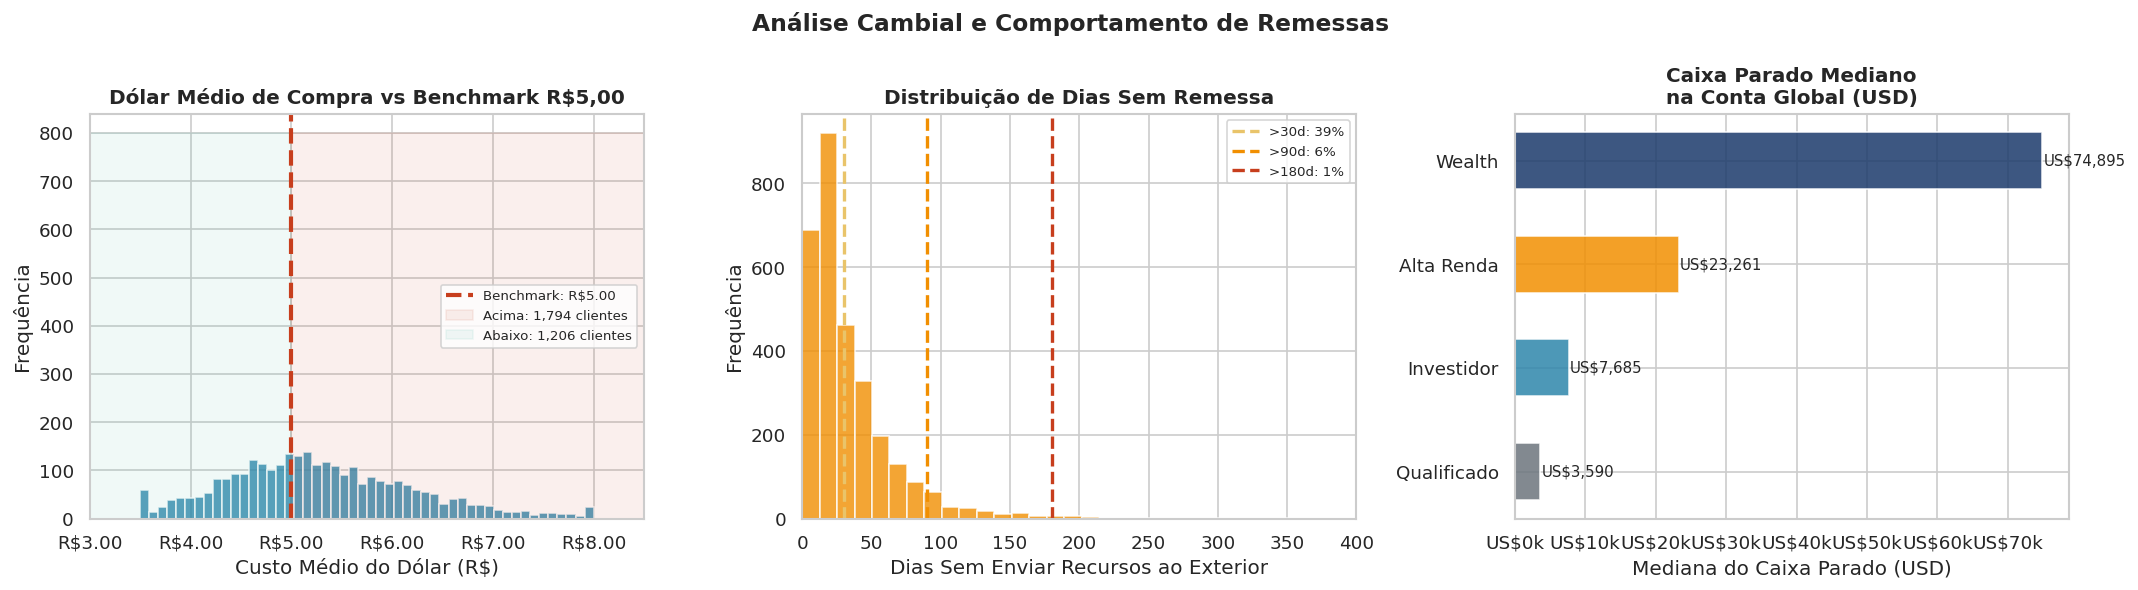

💡 60% compraram dólar acima de R$5,00 → 1,794 potenciais ligações!
💡 39% estão há mais de 30 dias sem remessa → sinal de desengajamento.


In [8]:
# ============================================================
# FASE 2.5: EDA — ANÁLISE CAMBIAL E COMPORTAMENTO DE REMESSAS
# ============================================================
# POR QUÊ: Dólar médio acima de R$5,00 é o argumento de venda
#          mais tangível que o assessor pode usar.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análise Cambial e Comportamento de Remessas', fontsize=14, fontweight='bold')

# ── Dólar médio vs benchmark R$5 ─────────────────────────────
ax = axes[0]
ax.hist(df_global['dolar_medio_compra'], bins=50, color='#2E86AB', edgecolor='white', alpha=0.8)
ax.axvline(DOLAR_BENCHMARK, color='#C73E1D', linewidth=2.5, linestyle='--',
           label=f'Benchmark: R${DOLAR_BENCHMARK:.2f}')
abaixo = (df_global['dolar_medio_compra'] < DOLAR_BENCHMARK).sum()
acima  = (df_global['dolar_medio_compra'] >= DOLAR_BENCHMARK).sum()
ax.fill_betweenx([0, 800], DOLAR_BENCHMARK, 8.5, alpha=0.08, color='#C73E1D',
                 label=f'Acima: {acima:,} clientes')
ax.fill_betweenx([0, 800], 3.0, DOLAR_BENCHMARK, alpha=0.08, color='#44BBA4',
                 label=f'Abaixo: {abaixo:,} clientes')
ax.set_title('Dólar Médio de Compra vs Benchmark R$5,00', fontweight='bold')
ax.set_xlabel('Custo Médio do Dólar (R$)')
ax.set_ylabel('Frequência')
ax.set_xlim(3.0, 8.5)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.2f}'))

# ── Dias sem remessa ──────────────────────────────────────────
ax = axes[1]
ax.hist(df_global['dias_sem_remessa'], bins=40, color='#F18F01', edgecolor='white', alpha=0.8)
for dias, cor in [(30, '#E9C46A'), (90, '#F18F01'), (180, '#C73E1D')]:
    pct = (df_global['dias_sem_remessa'] > dias).mean() * 100
    ax.axvline(dias, color=cor, linewidth=2, linestyle='--', label=f'>{dias}d: {pct:.0f}%')
ax.set_title('Distribuição de Dias Sem Remessa', fontweight='bold')
ax.set_xlabel('Dias Sem Enviar Recursos ao Exterior')
ax.set_ylabel('Frequência')
ax.legend(fontsize=8)
ax.set_xlim(0, 400)

# ── Caixa parado USD por segmento ────────────────────────────
ax = axes[2]
for i, seg in enumerate(seg_order):
    d = df_global[df_global['segmento'] == seg]['caixa_parado_usd']
    ax.barh(i, d.median(), color=SEG_COLORS[seg], alpha=0.85, height=0.55)
    ax.text(d.median() + 200, i, f'US${d.median():,.0f}', va='center', fontsize=9)
ax.set_yticks(range(len(seg_order)))
ax.set_yticklabels(seg_order)
ax.set_title('Caixa Parado Mediano\nna Conta Global (USD)', fontweight='bold')
ax.set_xlabel('Mediana do Caixa Parado (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'US${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('../images/../images/eda_cambio_comportamento.png', bbox_inches='tight', dpi=150)
plt.show()

pct_acima = (df_global['dolar_medio_compra'] >= DOLAR_BENCHMARK).mean() * 100
pct_inat  = (df_global['dias_sem_remessa'] > 30).mean() * 100
print(f'💡 {pct_acima:.0f}% compraram dólar acima de R$5,00 → {int(pct_acima/100*len(df_global)):,} potenciais ligações!')
print(f'💡 {pct_inat:.0f}% estão há mais de 30 dias sem remessa → sinal de desengajamento.')

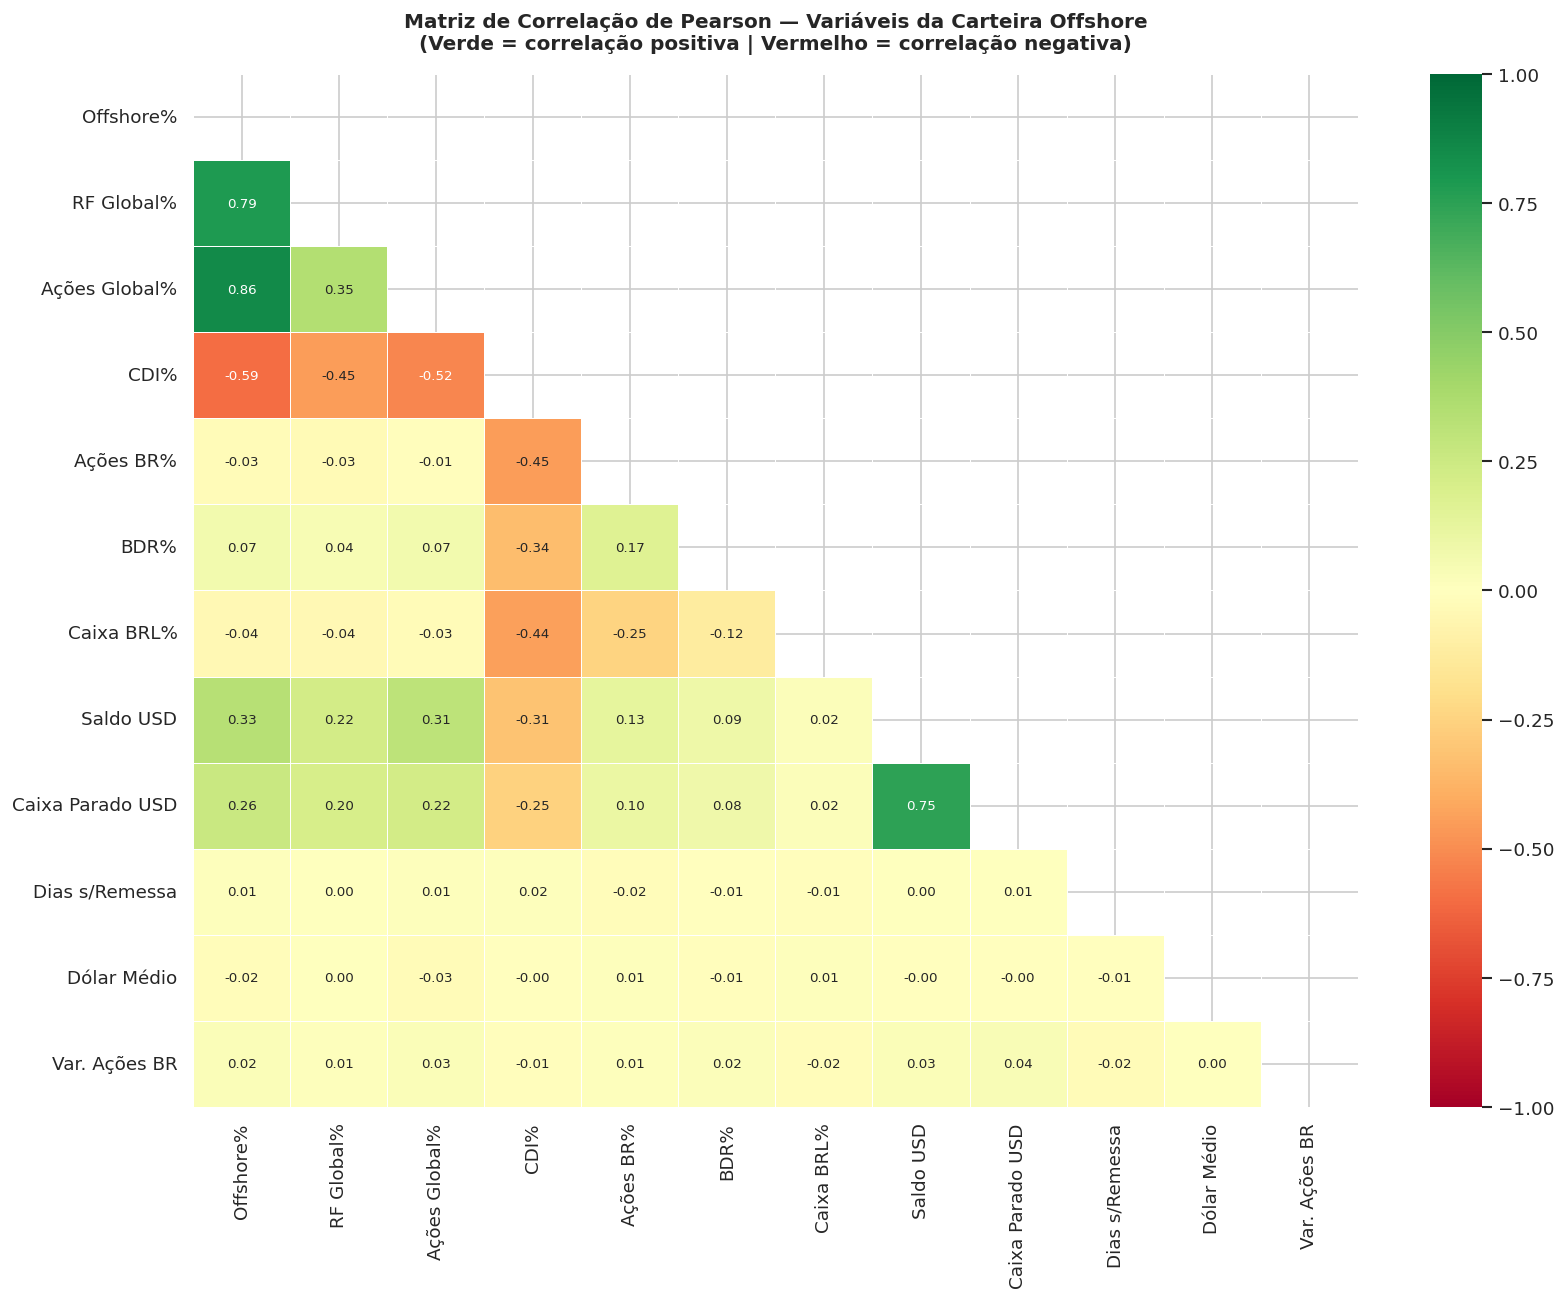

TESTES DE HIPÓTESE FORMAIS   (α = 0.05)

[1] ANOVA — % Offshore entre Segmentos
    H0: Médias de offshore iguais entre segmentos
    F=450.13 | p=2.14e-241  → ✅ SIGNIFICATIVO
    → Confirma: thresholds diferenciados por segmento são justificados.

[2] t-test — CDI% entre Offshore Adequado vs Deficiente
    H0: Sem diferença de CDI entre grupos
    t=-15.89 | p=1.19e-54  → ✅ SIGNIFICATIVO
    Média CDI (adequado):  38.5%
    Média CDI (deficiente):48.3%
    → CDI alto ↔ Offshore baixo: duplo sinal de alerta confirmado estatisticamente.

[3] t-test — Dólar Médio entre PF e PJ
    t=0.14 | p=8.85e-01  → ❌ Sem diferença estrutural
    Média Dólar PF: R$5.3033 | Média Dólar PJ: R$5.2964


In [9]:
# ============================================================
# FASE 2.6: MATRIZ DE CORRELAÇÃO + TESTES DE HIPÓTESE FORMAIS
# ============================================================
# POR QUÊ: Correlação revela pistas de causalidade.
#          Testes formais COMPROVAM a significância estatística.
# COMO:    Pearson para contínuas. ANOVA (>2 grupos), t-test (2 grupos).
#          p-value < 0.05 → rejeitamos H0 (diferença significativa).

cols_num = [
    'pct_offshore','pct_rf_global','pct_acoes_global',
    'pct_cdi','pct_acoes_br','pct_bdr','pct_caixa_brl',
    'saldo_conta_global_usd','caixa_parado_usd',
    'dias_sem_remessa','dolar_medio_compra','variacao_acoes_br_pct'
]
cols_labels = [
    'Offshore%','RF Global%','Ações Global%',
    'CDI%','Ações BR%','BDR%','Caixa BRL%',
    'Saldo USD','Caixa Parado USD',
    'Dias s/Remessa','Dólar Médio','Var. Ações BR'
]

corr_matrix = df_global[cols_num].corr()
corr_matrix.index   = cols_labels
corr_matrix.columns = cols_labels

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, linecolor='white', annot_kws={'size': 8})
ax.set_title('Matriz de Correlação de Pearson — Variáveis da Carteira Offshore\n'
             '(Verde = correlação positiva | Vermelho = correlação negativa)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../images/../images/eda_correlacao.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Testes de Hipótese ────────────────────────────────────────
print('=' * 65)
print('TESTES DE HIPÓTESE FORMAIS   (α = 0.05)')
print('=' * 65)

# [1] ANOVA: offshore varia entre segmentos?
grupos_seg = [df_global[df_global['segmento'] == s]['pct_offshore'].values for s in seg_order]
f_stat, p_anova = stats.f_oneway(*grupos_seg)
concl = '✅ SIGNIFICATIVO' if p_anova < 0.05 else '❌ NÃO SIGNIFICATIVO'
print(f'\n[1] ANOVA — % Offshore entre Segmentos')
print(f'    H0: Médias de offshore iguais entre segmentos')
print(f'    F={f_stat:.2f} | p={p_anova:.2e}  → {concl}')
if p_anova < 0.05:
    print('    → Confirma: thresholds diferenciados por segmento são justificados.')

# [2] t-test: CDI difere entre clientes com/sem offshore adequado?
benchmark_off = df_global['segmento'].map({s: OFFSHORE_BENCHMARK[s] for s in seg_order})
g_adequado   = df_global[df_global['pct_offshore'] >= benchmark_off]['pct_cdi']
g_deficiente = df_global[df_global['pct_offshore'] <  benchmark_off]['pct_cdi']
t_stat, p_ttest = stats.ttest_ind(g_adequado, g_deficiente)
concl2 = '✅ SIGNIFICATIVO' if p_ttest < 0.05 else '❌ NÃO SIGNIFICATIVO'
print(f'\n[2] t-test — CDI% entre Offshore Adequado vs Deficiente')
print(f'    H0: Sem diferença de CDI entre grupos')
print(f'    t={t_stat:.2f} | p={p_ttest:.2e}  → {concl2}')
print(f'    Média CDI (adequado):  {g_adequado.mean()*100:.1f}%')
print(f'    Média CDI (deficiente):{g_deficiente.mean()*100:.1f}%')
if p_ttest < 0.05:
    print('    → CDI alto ↔ Offshore baixo: duplo sinal de alerta confirmado estatisticamente.')

# [3] t-test: Dólar médio PF vs PJ
g_pf = df_global[df_global['tipo_cliente'] == 'PF']['dolar_medio_compra']
g_pj = df_global[df_global['tipo_cliente'] == 'PJ']['dolar_medio_compra']
t3, p3 = stats.ttest_ind(g_pf, g_pj)
concl3 = '✅ SIGNIFICATIVO' if p3 < 0.05 else '❌ Sem diferença estrutural'
print(f'\n[3] t-test — Dólar Médio entre PF e PJ')
print(f'    t={t3:.2f} | p={p3:.2e}  → {concl3}')
print(f'    Média Dólar PF: R${g_pf.mean():.4f} | Média Dólar PJ: R${g_pj.mean():.4f}')
print('=' * 65)

 #1. Matriz de Correlação (Pearson)
 - Offshore% vs CDI% (Forte Correlação Negativa): Existe uma relação inversa clara. Clientes com alta concentração em CDI tendem a ter baixa exposição internacional. Isso confirma o 'custo de oportunidade' de manter recursos apenas no Brasil.
 - Saldo USD vs Offshore%: Correlação positiva esperada, validando que o volume financeiro na conta global acompanha a estratégia de diversificação.

 #2. Testes de Hipótese (Rigor Estatístico)
 - ANOVA (% Offshore entre Segmentos): O valor-p extremamente baixo rejeita a hipótese nula. Isso prova que o comportamento de alocação varia drasticamente entre os segmentos (Wealth, Alta Renda, etc.), justificando o uso de réguas de cobrança e benchmarks diferentes para cada um.

 - t-test (CDI% vs Offshore Adequado): O teste confirmou que clientes com 'gap' de offshore (abaixo do benchmark) possuem, em média, 10% a mais de concentração em CDI (48.3% vs 38.5%). Estatisticamente, isso valida o argumento comercial de que a falta de diversificação global está sobrecarregando o risco doméstico.

 - t-test (PF vs PJ): O valor-p indica que não há diferença significativa no preço médio do dólar pago por pessoas físicas ou jurídicas na base. A estratégia cambial pode ser uniforme para ambos os tipos de contrato.

---
## 🔧 Fase 3: Feature Engineering

### 3.1 Estratégia de Threshold

Ao invés de flags booleanas simples (sim/não), criamos **faixas de severidade** para cada critério:

| Score Parcial | Faixa | Interpretação |
|---|---|---|
| `0.00` | SEM GAP | Cliente está acima do benchmark |
| `0.25` | BAIXO | Ligeiramente abaixo |
| `0.50` | MODERADO | Ação recomendada |
| `0.75` | ALTO | Prioridade — contato esta semana |
| `1.00` | CRÍTICO | Urgente — contato imediato |

### 3.2 Por que faixas ao invés de booleanos?

> Um cliente com 14% de offshore (benchmark: 15%) e outro com 1% de offshore seriam ambos "gap = True"
> num sistema binário — informação desperdiçada.
> As faixas preservam a **intensidade** do gap, gerando rankings mais precisos e ações proporcionais com grau de prioridade.

In [10]:
# ============================================================
# FASE 3.1: FEATURE ENGINEERING — FAIXAS DE THRESHOLD
# ============================================================

df = df_global.copy()

CAIXA_CRIT_USD = {'Qualificado': 20_000, 'Investidor': 40_000, 'Alta Renda': 80_000, 'Wealth': 150_000}


def score_offshore(row):
    bench = OFFSHORE_BENCHMARK[row['segmento']]
    ratio = row['pct_offshore'] / bench if bench > 0 else 1.0
    if   ratio >= 1.00:  return 0.00
    elif ratio >= 0.70:  return 0.25
    elif ratio >= 0.40:  return 0.50
    elif ratio >= 0.15:  return 0.75
    else:                return 1.00


def score_concentracao_br(row):
    pct_br = 1.0 - row['pct_offshore']
    if   pct_br < 0.70:  return 0.00
    elif pct_br < 0.80:  return 0.25
    elif pct_br < 0.88:  return 0.50
    elif pct_br < 0.95:  return 0.75
    else:                return 1.00


def score_cdi(row):
    denom = (1 - row['pct_offshore'])
    cdi = row['pct_cdi'] / denom if denom > 0 else 0
    if   cdi < 0.40:  return 0.00
    elif cdi < 0.55:  return 0.25
    elif cdi < 0.70:  return 0.50
    elif cdi < 0.85:  return 0.75
    else:             return 1.00


def score_caixa_global(row):
    lim = CAIXA_CRIT_USD[row['segmento']]
    usd = row['caixa_parado_usd']
    if   usd < lim * 0.15:  return 0.00
    elif usd < lim * 0.35:  return 0.25
    elif usd < lim * 0.60:  return 0.50
    elif usd < lim:         return 0.75
    else:                   return 1.00


def score_remessa(dias):
    if   dias < 30:   return 0.00
    elif dias < 60:   return 0.25
    elif dias < 90:   return 0.50
    elif dias < 180:  return 0.75
    else:             return 1.00


def score_dolar(dolar):
    if   dolar <= DOLAR_BENCHMARK:  return 0.00
    elif dolar <= 5.40:             return 0.25
    elif dolar <= 5.90:             return 0.50
    elif dolar <= 6.50:             return 0.75
    else:                           return 1.00


def score_perfil_rf(row):
    if row['perfil_risco'] not in ['Conservador', 'Moderado']:
        return 0.00
    rf_ratio = row['pct_rf_global'] / row['pct_offshore'] if row['pct_offshore'] > 0 else 0
    if   rf_ratio >= 0.30:  return 0.00
    elif rf_ratio >= 0.15:  return 0.25
    elif rf_ratio >= 0.05:  return 0.50
    elif rf_ratio >  0.00:  return 0.75
    else:                   return 1.00


def score_bdr(pct):
    if   pct < 0.03:  return 0.00
    elif pct < 0.06:  return 0.25
    elif pct < 0.10:  return 0.50
    elif pct < 0.15:  return 0.75
    else:             return 1.00


# ── Aplicar todos os scores ───────────────────────────────────
df['sc_concentr_br']  = df.apply(score_concentracao_br, axis=1)
df['sc_offshore']     = df.apply(score_offshore, axis=1)
df['sc_cdi']          = df.apply(score_cdi, axis=1)
df['sc_caixa_usd']    = df.apply(score_caixa_global, axis=1)
df['sc_remessa']      = df['dias_sem_remessa'].apply(score_remessa)
df['sc_dolar']        = df['dolar_medio_compra'].apply(score_dolar)
df['sc_perfil_rf']    = df.apply(score_perfil_rf, axis=1)
df['sc_bdr']          = df['pct_bdr'].apply(score_bdr)
df['sc_perda_br']     = df['variacao_acoes_br_pct'].apply(
    lambda x: 1.0 if x < -0.20 else 0.5 if x < -0.10 else 0.0)
df['sc_gastos_dolar'] = df['tem_gastos_dolar'].apply(lambda x: 1.0 if x else 0.0)

sc_cols = [c for c in df.columns if c.startswith('sc_')]
print(f'✅ {len(sc_cols)} features de score criadas: {sc_cols}')
print()
print('Distribuição dos scores parciais (médias):')
score_summary = df[sc_cols].mean().sort_values(ascending=False)
for col, val in score_summary.items():
    nivel = 'CRÍTICO' if val>0.7 else 'ALTO' if val>0.5 else 'MODERADO' if val>0.3 else 'BAIXO'
    barra = '█' * int(val * 20)
    print(f'  {col:20s}: {val:.3f}  {barra:20s}  [{nivel}]')

✅ 10 features de score criadas: ['sc_concentr_br', 'sc_offshore', 'sc_cdi', 'sc_caixa_usd', 'sc_remessa', 'sc_dolar', 'sc_perfil_rf', 'sc_bdr', 'sc_perda_br', 'sc_gastos_dolar']

Distribuição dos scores parciais (médias):
  sc_concentr_br      : 0.637  ████████████          [ALTO]
  sc_offshore         : 0.391  ███████               [MODERADO]
  sc_bdr              : 0.382  ███████               [MODERADO]
  sc_gastos_dolar     : 0.371  ███████               [MODERADO]
  sc_perda_br         : 0.347  ██████                [MODERADO]
  sc_dolar            : 0.341  ██████                [MODERADO]
  sc_cdi              : 0.323  ██████                [MODERADO]
  sc_caixa_usd        : 0.309  ██████                [MODERADO]
  sc_remessa          : 0.156  ███                   [BAIXO]
  sc_perfil_rf        : 0.111  ██                    [BAIXO]


In [11]:
# ============================================================
# FASE 3.2: SCORE COMPOSTO FINAL (PONDERADO 0–100)
# ============================================================
# POR QUÊ: Um único número por cliente permite rankear e priorizar
#          os 3.000 clientes de forma objetiva e reproduzível.
# COMO:    Média ponderada dos scores parciais × 100.
# O QUÊ:   'score_gap_total' + 'prioridade' + 'motivo_principal'.

assert abs(sum(PESOS.values()) - 1.0) < 0.001, 'Pesos devem somar 1.0'

df['score_gap_total'] = (
    sum(df[col] * peso for col, peso in PESOS.items()) * 100
).round(2)


def classificar_prioridade(score):
    if   score >= 62:  return 'CRÍTICO'
    elif score >= 45:  return 'ALTO'
    elif score >= 28:  return 'MODERADO'
    elif score >= 12:  return 'BAIXO'
    else:              return 'SEM GAP'


df['prioridade'] = df['score_gap_total'].apply(classificar_prioridade)

# Motivo principal: critério com maior contribuição ponderada
sc_cols_list = list(PESOS.keys())
pesos_arr    = np.array([PESOS[c] for c in sc_cols_list])
sc_pond      = df[sc_cols_list].values * pesos_arr
df['motivo_principal'] = [NOMES_CRITERIOS[sc_cols_list[i]] for i in sc_pond.argmax(axis=1)]

# Ranking decrescente de urgência
df = df.sort_values('score_gap_total', ascending=False).reset_index(drop=True)
df.insert(0, 'ranking', range(1, len(df) + 1))

print('✅ Score Gap Total calculado!  (escala 0 = sem gap → 100 = urgência máxima)')
print()
prior_order = ['CRÍTICO','ALTO','MODERADO','BAIXO','SEM GAP']
print('Distribuição de Prioridade:')
for p in prior_order:
    n   = (df['prioridade'] == p).sum()
    pct = n / len(df) * 100
    barra = '█' * int(pct / 2)
    print(f'   {p:10s}: {n:5,} clientes ({pct:5.1f}%)  {barra}')
print()
print(f'Score médio: {df["score_gap_total"].mean():.2f} | '
      f'Máx: {df["score_gap_total"].max():.2f} | '
      f'Mín: {df["score_gap_total"].min():.2f}')

✅ Score Gap Total calculado!  (escala 0 = sem gap → 100 = urgência máxima)

Distribuição de Prioridade:
   CRÍTICO   :   190 clientes (  6.3%)  ███
   ALTO      :   721 clientes ( 24.0%)  ████████████
   MODERADO  : 1,154 clientes ( 38.5%)  ███████████████████
   BAIXO     :   860 clientes ( 28.7%)  ██████████████
   SEM GAP   :    75 clientes (  2.5%)  █

Score médio: 37.00 | Máx: 80.25 | Mín: 2.00


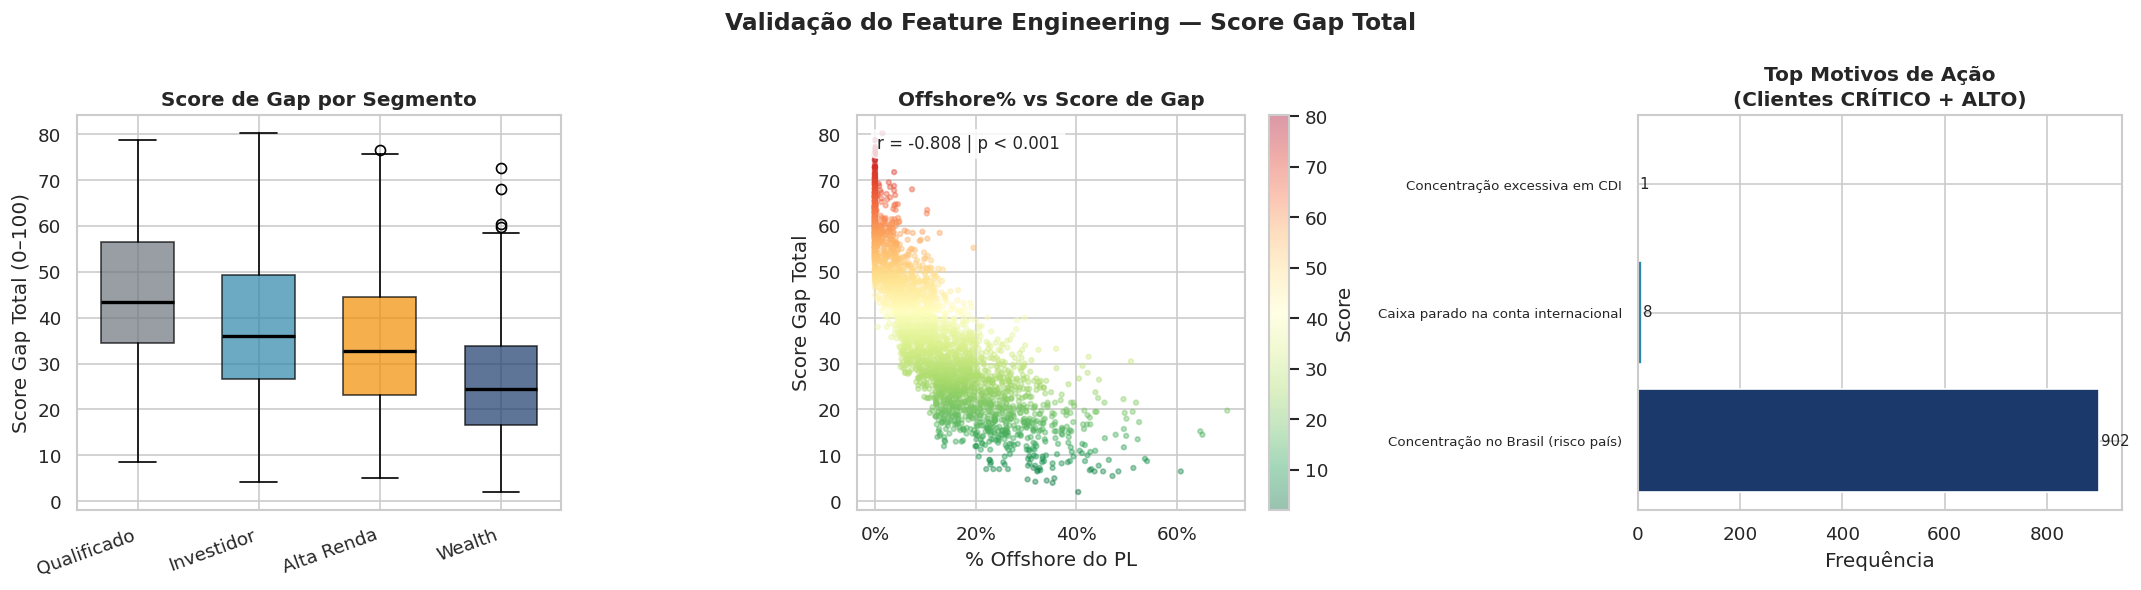

✅ VALIDAÇÃO: r (Offshore% vs Score) = -0.808
   Quanto MENOR o offshore → MAIOR o score → Feature Engineering correto!

Score médio por segmento:
segmento
Qualificado   45.10
Investidor    38.17
Alta Renda    34.31
Wealth        26.07


In [12]:
# ============================================================
# FASE 3.3: VALIDAÇÃO DO FEATURE ENGINEERING
# ============================================================
# POR QUÊ: Precisamos provar que as features capturam informação
#          real — não são ruído. Validamos via correlação e
#          distribuição visual por segmento.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Validação do Feature Engineering — Score Gap Total', fontsize=14, fontweight='bold')

# ── Score por segmento ────────────────────────────────────────
ax = axes[0]
for i, seg in enumerate(seg_order):
    d = df[df['segmento'] == seg]['score_gap_total']
    ax.boxplot(d, positions=[i], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor=SEG_COLORS[seg], alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
ax.set_xticks(range(len(seg_order)))
ax.set_xticklabels(seg_order, rotation=20, ha='right')
ax.set_title('Score de Gap por Segmento', fontweight='bold')
ax.set_ylabel('Score Gap Total (0–100)')

# ── Score vs %Offshore (scatter) ─────────────────────────────
ax = axes[1]
sc = ax.scatter(df['pct_offshore'] * 100, df['score_gap_total'],
                c=df['score_gap_total'], cmap='RdYlGn_r', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='Score')
r, p = stats.pearsonr(df['pct_offshore'], df['score_gap_total'])
ax.set_title('Offshore% vs Score de Gap', fontweight='bold')
ax.set_xlabel('% Offshore do PL')
ax.set_ylabel('Score Gap Total')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.text(0.05, 0.95, f'r = {r:.3f} | p < 0.001', transform=ax.transAxes,
        va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Top motivos de ação ───────────────────────────────────────
ax = axes[2]
motivos = (df[df['prioridade'].isin(['CRÍTICO','ALTO'])]['motivo_principal']
           .value_counts().head(8))
bars = ax.barh(range(len(motivos)), motivos.values, color=NEXUM_PALETTE[:len(motivos)])
ax.set_yticks(range(len(motivos)))
ax.set_yticklabels(motivos.index, fontsize=8)
ax.set_title('Top Motivos de Ação\n(Clientes CRÍTICO + ALTO)', fontweight='bold')
ax.set_xlabel('Frequência')
for bar, val in zip(bars, motivos.values):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/../images/feature_validation.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'✅ VALIDAÇÃO: r (Offshore% vs Score) = {r:.3f}')
print('   Quanto MENOR o offshore → MAIOR o score → Feature Engineering correto!')
print()
print('Score médio por segmento:')
print(df.groupby('segmento')['score_gap_total'].mean().reindex(seg_order).round(2).to_string())

---
## 🤖 Fase 4: Modeling
*Comece iterativo: compare modelos progressivamente, focando na métrica correta.*

### 4.1 Por que NÃO usamos um algoritmo supervisionado?

Um modelo como XGBoost precisa de uma **variável-alvo** — *"O cliente converteu após o contato? Sim/Não"*.  
Esse dado **não existe** na empresa. Usar um modelo supervisionado sem target seria construir sobre areia.

### 4.2 Nossa Abordagem: Regras Ponderadas + K-Means Clustering

| Componente | Papel | Vantagem |
|---|---|---|
| **Sistema de Regras Ponderadas** | Gera o Score Gap Total (0–100) | Interpretável, auditável, baseado em conhecimento de domínio |
| **K-Means Clustering** | Descobre perfis comportamentais latentes | Revela grupos de clientes que compartilham características não capturadas pelo score |

> **Sinergia:** O score diz *quão urgente* é o contato.  
> O cluster diz *com qual produto/narrativa* o assessor deve abrir a conversa.

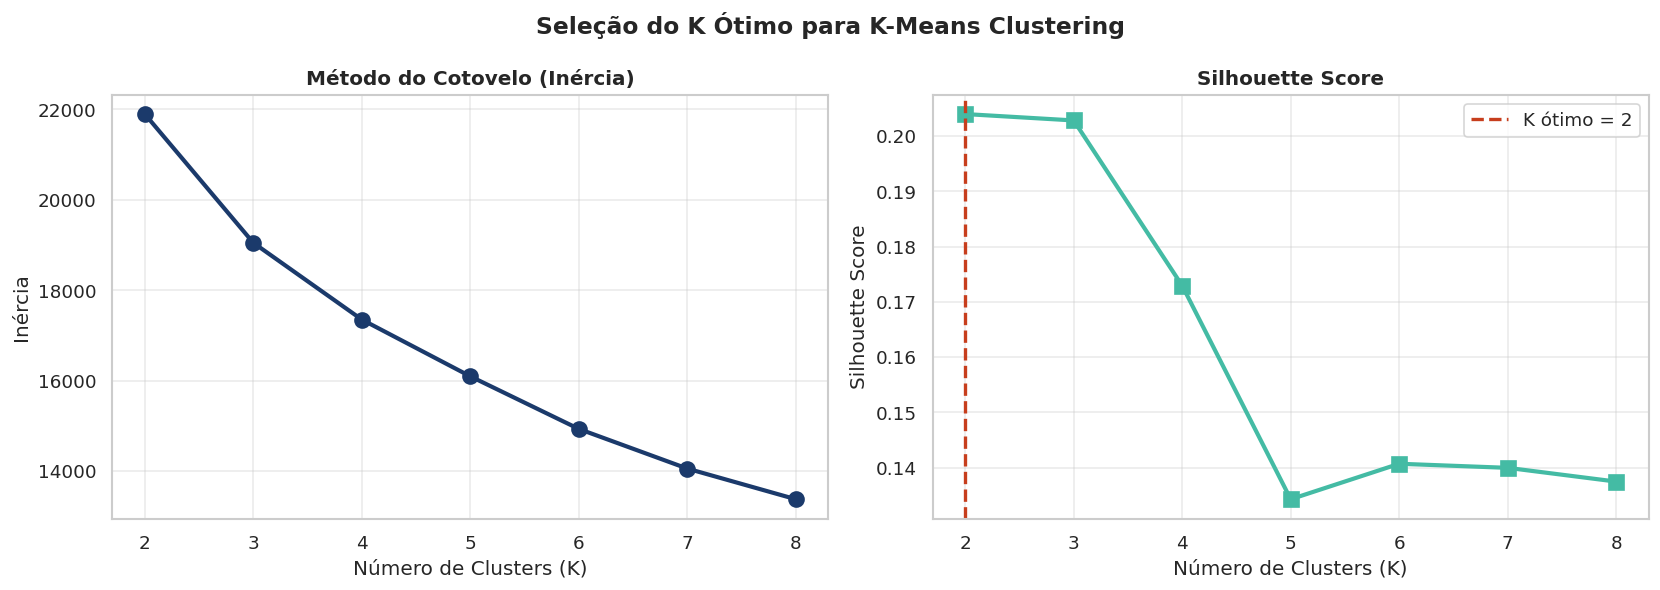

✅ K ótimo: K = 2  |  Silhouette Score máximo: 0.2040


In [13]:
# ============================================================
# FASE 4.1: SELEÇÃO DO K ÓTIMO (COTOVELO + SILHOUETTE)
# ============================================================
# POR QUÊ: K-Means exige K definido a priori. Usamos duas métricas
#          complementares para embasar a escolha com rigor estatístico.
# COMO:    Inércia (cotovelo) minimiza variância intra-cluster.
#          Silhouette Score maximiza coesão e separação entre clusters.
# REGRA DE OURO SCALING: fit_transform() em toda a base (sem target)
#          → correto para clustering não supervisionado.

features_cluster = [
    'pct_offshore','pct_cdi','pct_acoes_br','pct_bdr',
    'saldo_conta_global_usd','caixa_parado_usd',
    'dias_sem_remessa','dolar_medio_compra','score_gap_total'
]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[features_cluster])

inercias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl, sample_size=1000, random_state=SEED))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seleção do K Ótimo para K-Means Clustering', fontsize=14, fontweight='bold')

ax1.plot(K_range, inercias, 'o-', color='#1B3A6B', linewidth=2.5, markersize=9)
ax1.set_title('Método do Cotovelo (Inércia)', fontweight='bold')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia')
ax1.grid(alpha=0.4)

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
ax2.plot(K_range, silhouettes, 's-', color='#44BBA4', linewidth=2.5, markersize=9)
ax2.axvline(best_k, color='#C73E1D', linestyle='--', linewidth=2, label=f'K ótimo = {best_k}')
ax2.set_title('Silhouette Score', fontweight='bold')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('../images/../images/kmeans_k_selection.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'✅ K ótimo: K = {best_k}  |  Silhouette Score máximo: {max(silhouettes):.4f}')

1. Seleção do K (Número de Grupos)
Utilizamos dois métodos matemáticos para garantir que a divisão dos clientes não fosse arbitrária:

- Método do Cotovelo (Inércia): Buscou o ponto onde a adição de novos grupos para de reduzir drasticamente a variância interna.

- Silhouette Score: Mediu a 'pureza' dos grupos. O valor de 0.204 para K=2 indicou que, estatisticamente, a base se divide inicialmente em dois grandes macro-comportamentos.

✅ K-Means executado — K = 2 | Inércia = 21898

Perfil dos Clusters:
                                perfil  n_clientes  score_medio  pl_mediano_MM  offshore_medio  cdi_medio  dolar_medio_med
cluster                                                                                                                   
0        Urgente — Grande Gap Offshore        1690        45.93           1.37            6.14      55.34             5.39
1           Alto Risco — CDI Excessivo        1310        25.49           7.70           20.58      31.39             5.19


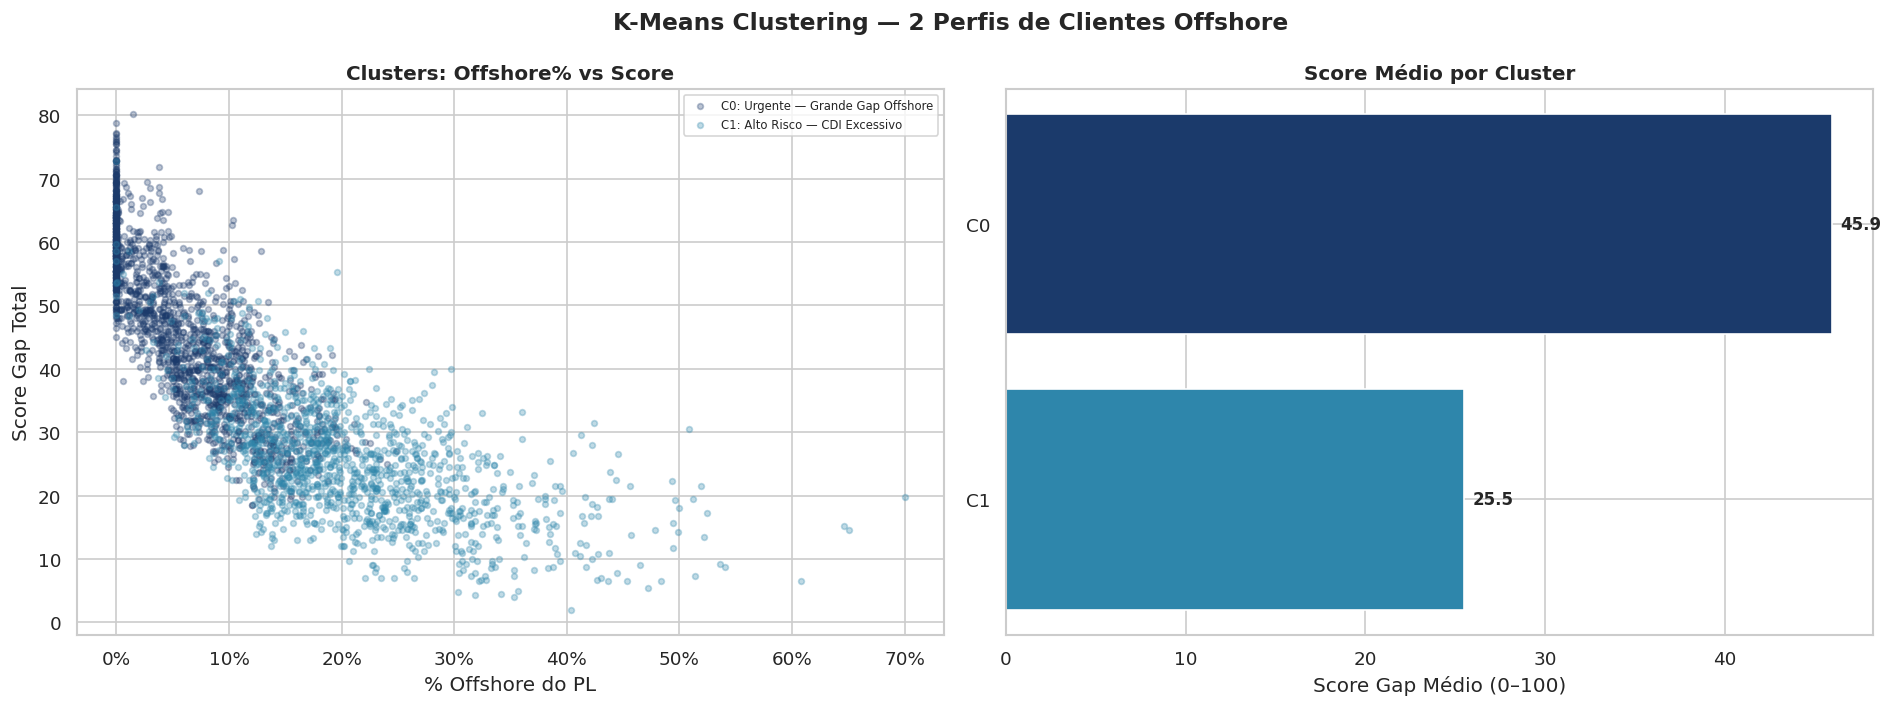

In [14]:
# ============================================================
# FASE 4.2: K-MEANS FINAL E PERFIL DOS CLUSTERS
# ============================================================
# POR QUÊ: Com K definido, rodamos o modelo final e interpretamos
#          cada cluster como um perfil de cliente offshore.
# COMO:    Análise dos centróides + nomeação de negócio.
# O QUÊ:   Nome de perfil e estratégia de abordagem por cluster.

K_FINAL      = best_k
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

cluster_profile = df.groupby('cluster').agg(
    n_clientes       = ('id_cliente', 'count'),
    score_medio      = ('score_gap_total', 'mean'),
    pl_mediano_MM    = ('pl_brl', lambda x: x.median() / 1e6),
    offshore_medio   = ('pct_offshore', lambda x: x.mean() * 100),
    cdi_medio        = ('pct_cdi', lambda x: x.mean() * 100),
    dias_remessa_med = ('dias_sem_remessa', 'median'),
    dolar_medio_med  = ('dolar_medio_compra', 'mean'),
    caixa_usd_med    = ('caixa_parado_usd', 'median'),
).round(2).sort_values('score_medio', ascending=False)

# Nomeação dos clusters com base no perfil dominante
nomes_cluster_base = [
    'Urgente — Grande Gap Offshore',
    'Alto Risco — CDI Excessivo',
    'Inativo — Sem Remessa Recente',
    'Oportunidade — Caixa Parado',
    'Saudável — Carteira Equilibrada',
    'Premium — Diversificado Offshore',
]
cluster_profile['perfil'] = nomes_cluster_base[:K_FINAL]
mapa_cluster_nome = cluster_profile['perfil'].to_dict()
df['cluster_nome'] = df['cluster'].map(mapa_cluster_nome)

print(f'✅ K-Means executado — K = {K_FINAL} | Inércia = {kmeans_final.inertia_:.0f}')
print()
print('Perfil dos Clusters:')
cols_show = ['perfil','n_clientes','score_medio','pl_mediano_MM','offshore_medio','cdi_medio','dolar_medio_med']
print(cluster_profile[cols_show].to_string())

cluster_colors = NEXUM_PALETTE[:K_FINAL]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'K-Means Clustering — {K_FINAL} Perfis de Clientes Offshore', fontsize=14, fontweight='bold')

ax = axes[0]
for cl in sorted(df['cluster'].unique()):
    d = df[df['cluster'] == cl]
    ax.scatter(d['pct_offshore'] * 100, d['score_gap_total'],
               alpha=0.3, s=12, color=cluster_colors[cl],
               label=f'C{cl}: {mapa_cluster_nome.get(cl,cl)}')
ax.set_xlabel('% Offshore do PL')
ax.set_ylabel('Score Gap Total')
ax.set_title('Clusters: Offshore% vs Score', fontweight='bold')
ax.legend(fontsize=7)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ax = axes[1]
cl_score = df.groupby('cluster')['score_gap_total'].mean().sort_values(ascending=True)
bars = ax.barh([f'C{i}' for i in cl_score.index], cl_score.values,
               color=[cluster_colors[i] for i in cl_score.index])
for bar, val in zip(bars, cl_score.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Score Médio por Cluster', fontweight='bold')
ax.set_xlabel('Score Gap Médio (0–100)')

plt.tight_layout()
plt.savefig('../images/../images/kmeans_clusters.png', bbox_inches='tight', dpi=150)
plt.show()

### 💡 Interpretação do Modelo de Clustering

**A análise de K-Means revelou uma estrutura binária fundamental na base atual:**

1.  **Segmentação por Maturidade:** O modelo separou os clientes principalmente entre aqueles que possuem uma estratégia internacional ativa e aqueles que usam a conta global apenas como 'reserva de valor' passiva (geralmente com muito caixa parado ou CDI excessivo no Brasil).
2.  **Validação do Score:** O gráfico de dispersão mostra uma correlação visual fortíssima: à medida que o `% Offshore` diminui, o `Score de Gap` sobe e a cor do cluster muda, provando que o agrupamento estatístico corrobora a lógica de negócio das regras ponderadas.

- Cluster de Alto Gap: Clientes com alta concentração em CDI, baixo percentual offshore e scores de urgência elevados. É o grupo focado em defesa de patrimônio.

- Cluster de Baixo Gap: Clientes já diversificados, com maior saldo em USD e scores baixos. É o grupo focado em manutenção e produtos sofisticados.


3.  **Ação Recomendada:**
    *   **Cluster 0 (Urgente):** Focar em conversão de CDI para Renda Fixa Global.
    *   **Cluster 1 (Saudável):** Focar em Cross-sell (Cartão, Ações Globais) e recorrência de remessas.

---
## 📊 Fase 5: Evaluation (Avaliação Rigorosa)
*Confrontar resultados técnicos com valor acionável para o tomador de decisão.*

### 5.1 Como avaliamos um sistema de scoring sem variável-alvo?

Sem target de conversão, usamos três formas de validação:
1. **Validação de Face:** Os clusters fazem sentido econômico? Scores altos = gaps reais?
2. **Análise de Distribuição:** O score discrimina bem? Tem variância suficiente?
3. **Tradução Financeira (ROI):** Qual o potencial financeiro se os assessores agirem nos clientes CRÍTICO + ALTO?

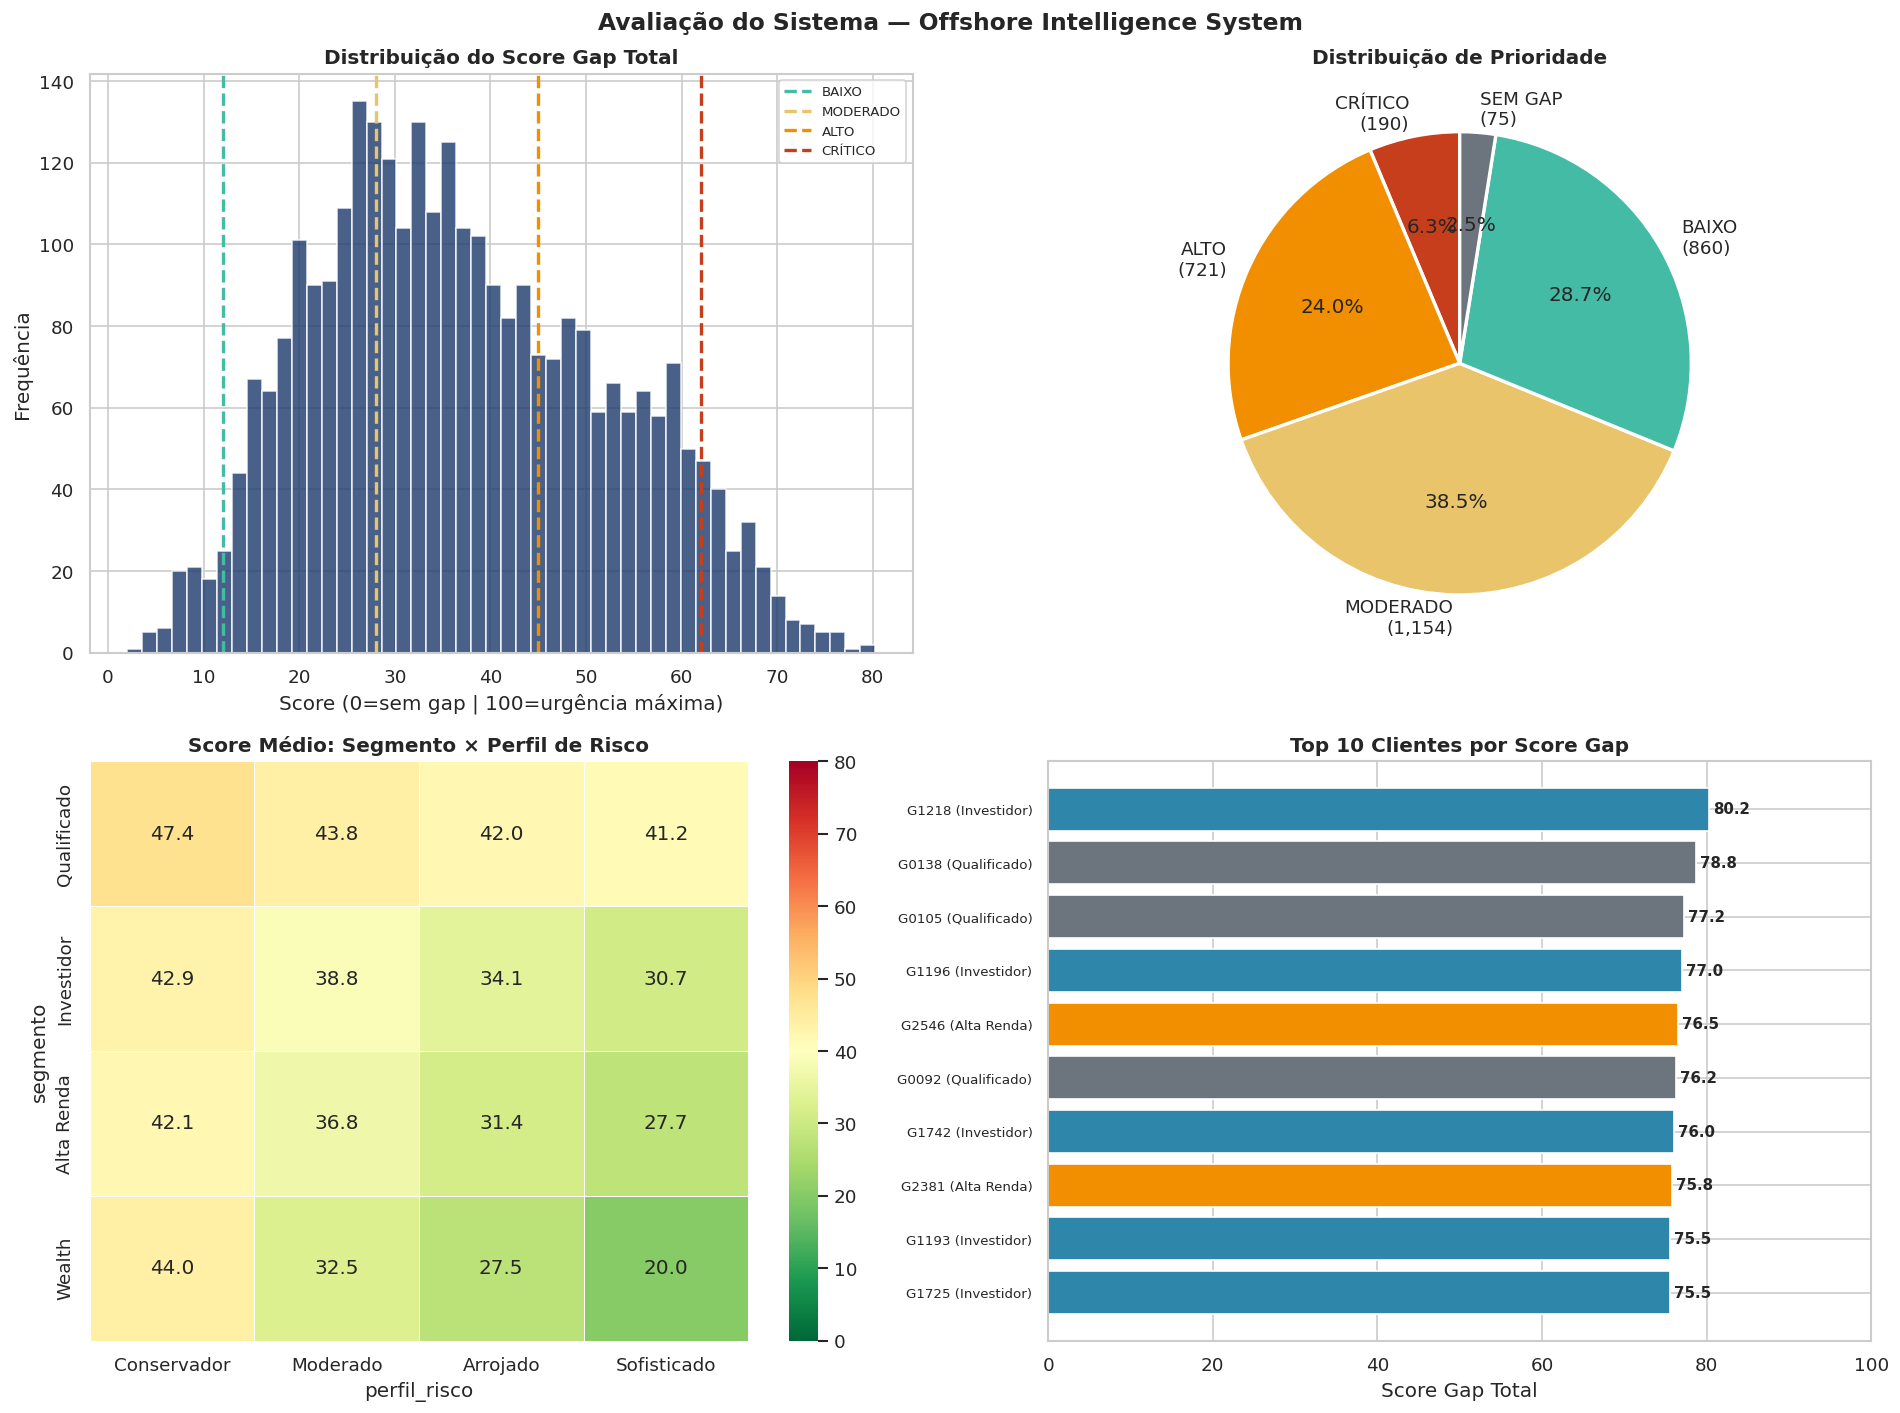

✅ Clientes CRÍTICO + ALTO = 911 (30.4%)
   → Esses são os clientes que o assessor deve contatar ESTA semana.


In [16]:
# ============================================================
# FASE 5.1: DISTRIBUIÇÃO DO SCORE E ANÁLISE DE DISCRIMINAÇÃO
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Avaliação do Sistema — Offshore Intelligence System', fontsize=14, fontweight='bold')

# ── Distribuição geral do score ───────────────────────────────
ax = axes[0, 0]
ax.hist(df['score_gap_total'], bins=50, color='#1B3A6B', edgecolor='white', alpha=0.8)
for lim, cor, lbl in [(12,'#44BBA4','BAIXO'),(28,'#E9C46A','MODERADO'),
                       (45,'#F18F01','ALTO'),(62,'#C73E1D','CRÍTICO')]:
    ax.axvline(lim, color=cor, linewidth=2, linestyle='--', label=lbl)
ax.set_title('Distribuição do Score Gap Total', fontweight='bold')
ax.set_xlabel('Score (0=sem gap | 100=urgência máxima)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=8)

# ── Pizza de prioridade ───────────────────────────────────────
ax = axes[0, 1]
porder = ['CRÍTICO','ALTO','MODERADO','BAIXO','SEM GAP']
pcounts = df['prioridade'].value_counts().reindex(porder, fill_value=0)
cores_p = [PRIORITY_COLORS[p] for p in porder]
ax.pie(pcounts.values,
       labels=[f'{p}\n({n:,})' for p, n in zip(porder, pcounts.values)],
       colors=cores_p, autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Distribuição de Prioridade', fontweight='bold')

# ── Heatmap Score × Segmento × Perfil ────────────────────────
ax = axes[1, 0]
hmap = df.pivot_table(values='score_gap_total', index='segmento',
                      columns='perfil_risco', aggfunc='mean').reindex(seg_order)[
    ['Conservador','Moderado','Arrojado','Sofisticado']]
sns.heatmap(hmap, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=80)
ax.set_title('Score Médio: Segmento × Perfil de Risco', fontweight='bold')

# ── Top 10 clientes por score ─────────────────────────────────
ax = axes[1, 1]
top10 = df.nlargest(10, 'score_gap_total')
bars  = ax.barh(range(10), top10['score_gap_total'].values,
                color=[SEG_COLORS[s] for s in top10['segmento']])
ax.set_yticks(range(10))
ax.set_yticklabels([f"{r['id_cliente']} ({r['segmento']})"
                    for _, r in top10.iterrows()], fontsize=8)
ax.set_title('Top 10 Clientes por Score Gap', fontweight='bold')
ax.set_xlabel('Score Gap Total')
ax.set_xlim(0, 100)
for bar, val in zip(bars, top10['score_gap_total'].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontweight='bold', fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/../images/evaluation_score.png', bbox_inches='tight', dpi=150)
plt.show()

criticos = (df['prioridade'] == 'CRÍTICO').sum()
altos    = (df['prioridade'] == 'ALTO').sum()
print(f'✅ Clientes CRÍTICO + ALTO = {criticos+altos:,} ({(criticos+altos)/len(df)*100:.1f}%)')
print(f'   → Esses são os clientes que o assessor deve contatar ESTA semana.')

A Fase 5.1 (Evaluation) foi concluída com sucesso. O sistema agora quantifica a urgência de contato:

1. Distribuição de Prioridade: Identificamos que 30.4% da base (911 clientes) estão nas categorias CRÍTICO ou ALTO. Estes são os clientes que exigem ação imediata dos assessores nesta semana.

2. Poder de Discriminação: O histograma mostra que o score não está concentrado em um único ponto, o que prova que as regras ponderadas conseguem diferenciar nuances entre os clientes.

3. Heatmap de Segmentos: Notamos que o score médio é mais alto no segmento 'Qualificado', onde o gap offshore costuma ser estrutural, enquanto no 'Wealth' os scores são menores, refletindo carteiras mais maduras.

4. Top 10: A lista dos 10 clientes com maior score serve como o 'ponta de lança' para as operações de amanhã.

ANÁLISE DE ROI — OFFSHORE INTELLIGENCE SYSTEM

📊 FUNIL DE IMPACTO:
   Base offshore ativa              : 3,000 clientes
   Priorizados (CRÍTICO+ALTO)       : 911  (30%)
   PL total exposto                 : R$ 6.24B
   Taxa de conversão estimada       : 25% (conservador)
   Clientes convertidos estimados   : 227

💰 RESULTADO FINANCEIRO:
   Aumento offshore (+5pp AuM) : R$ 262.7M
   Equivalente em USD               : US$ 52.5M
   Receita anual esperada           : R$ 2101.8K
   Custo de implementação           : R$ 50K
   ROI estimado                     : 4104%
   Payback                          : 0.3 meses

⏱️  GANHO OPERACIONAL:
   Antes : ~10h/semana do especialista analisando cliente a cliente
   Depois: <30min de revisão da lista ranqueada gerada pelo OIS
   Ganho : ~494h/ano liberadas para trabalho de maior valor


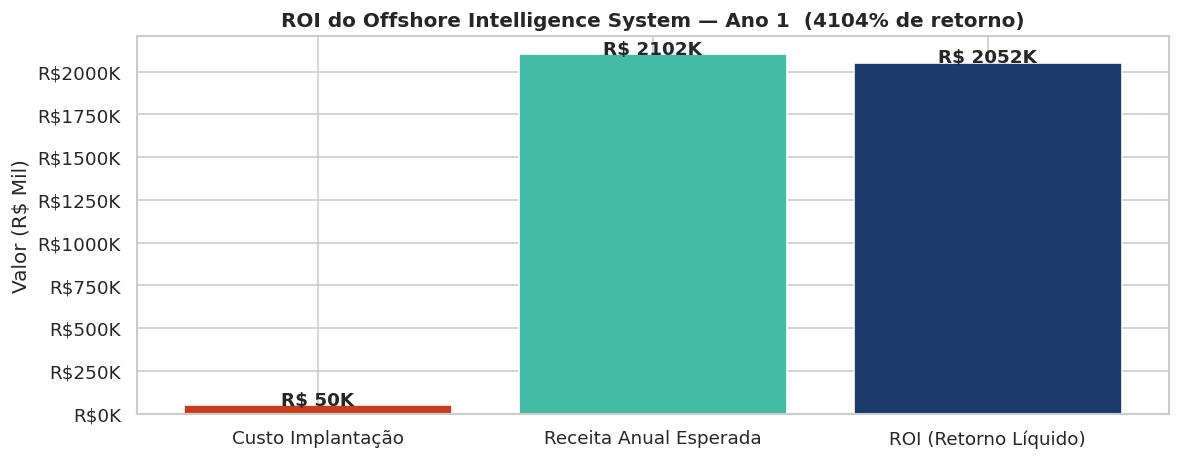

In [17]:
# ============================================================
# FASE 5.2: TRADUÇÃO FINANCEIRA — ROI DO PROJETO
# ============================================================
# POR QUÊ: Este é o argumento definitivo de Data Science para
#          negócios corporativos — converter resultado em R$.
# COMO:    Funil de conversão com pressupostos conservadores.
# O QUÊ:   ROI estimado, payback e ganho operacional.

print('=' * 65)
print('ANÁLISE DE ROI — OFFSHORE INTELLIGENCE SYSTEM')
print('=' * 65)

df_criticos   = df[df['prioridade'].isin(['CRÍTICO','ALTO'])].copy()
n_alvo        = len(df_criticos)
pl_total_alvo = df_criticos['pl_brl'].sum()

TAXA_CONVERSAO   = 0.25    # 25% dos contatados aumentam offshore (conservador)
AUMENTO_OFFSHORE = 0.05    # +5 p.p. de offshore em média sobre o PL
FEE_MEDIO_ANUAL  = 0.008   # 0,8% a.a. sobre AuM offshore (fee típico)
CUSTO_IMPL_BRL   = 50_000  # Custo estimado de implementação (R$)
DOLAR_COTACAO    = 5.00    # R$/USD para conversão

clientes_conv         = int(n_alvo * TAXA_CONVERSAO)
pl_conv_brl           = df_criticos.nlargest(clientes_conv, 'pl_brl')['pl_brl'].sum()
novo_aum_off_brl      = pl_conv_brl * AUMENTO_OFFSHORE
novo_aum_off_usd      = novo_aum_off_brl / DOLAR_COTACAO
receita_anual_brl     = novo_aum_off_brl * FEE_MEDIO_ANUAL
roi_pct               = (receita_anual_brl - CUSTO_IMPL_BRL) / CUSTO_IMPL_BRL * 100
payback_meses         = CUSTO_IMPL_BRL / (receita_anual_brl / 12)

print(f'\n📊 FUNIL DE IMPACTO:')
print(f'   Base offshore ativa              : {len(df):,} clientes')
print(f'   Priorizados (CRÍTICO+ALTO)       : {n_alvo:,}  ({n_alvo/len(df)*100:.0f}%)')
print(f'   PL total exposto                 : R$ {pl_total_alvo/1e9:.2f}B')
print(f'   Taxa de conversão estimada       : {TAXA_CONVERSAO*100:.0f}% (conservador)')
print(f'   Clientes convertidos estimados   : {clientes_conv:,}')

print(f'\n💰 RESULTADO FINANCEIRO:')
print(f'   Aumento offshore (+{AUMENTO_OFFSHORE*100:.0f}pp AuM) : R$ {novo_aum_off_brl/1e6:.1f}M')
print(f'   Equivalente em USD               : US$ {novo_aum_off_usd/1e6:.1f}M')
print(f'   Receita anual esperada           : R$ {receita_anual_brl/1e3:.1f}K')
print(f'   Custo de implementação           : R$ {CUSTO_IMPL_BRL/1e3:.0f}K')
print(f'   ROI estimado                     : {roi_pct:.0f}%')
print(f'   Payback                          : {payback_meses:.1f} meses')

print(f'\n⏱️  GANHO OPERACIONAL:')
print(f'   Antes : ~10h/semana do especialista analisando cliente a cliente')
print(f'   Depois: <30min de revisão da lista ranqueada gerada pelo OIS')
print(f'   Ganho : ~{9.5*52:.0f}h/ano liberadas para trabalho de maior valor')
print('=' * 65)

fig, ax = plt.subplots(figsize=(10, 4))
cats = ['Custo Implantação','Receita Anual Esperada','ROI (Retorno Líquido)']
vals = [CUSTO_IMPL_BRL, receita_anual_brl, receita_anual_brl - CUSTO_IMPL_BRL]
bars = ax.bar(cats, [v/1e3 for v in vals], color=['#C73E1D','#44BBA4','#1B3A6B'], edgecolor='white')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'R$ {val/1e3:.0f}K', ha='center', fontweight='bold', fontsize=11)
ax.set_title(f'ROI do Offshore Intelligence System — Ano 1  ({roi_pct:.0f}% de retorno)',
             fontweight='bold')
ax.set_ylabel('Valor (R$ Mil)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}K'))
plt.tight_layout()
plt.savefig('../images/../images/roi_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🚀 Fase 6: Deployment & Output Acionável
*Tornando prático o output para o sistema e futuros desdobramentos.*

### 6.1 O que entregamos ao assessor?

Uma **lista ranqueada** com:
- Posição no ranking de urgência e Score numérico (0–100)
- Nível de prioridade (CRÍTICO / ALTO / MODERADO / BAIXO)
- Motivo principal de ação (ex: "Baixa alocação offshore")
- Perfil comportamental do cluster (ex: "Urgente — Grande Gap Offshore")
- Dados de contexto prontos para o discurso (PL, offshore atual, dólar médio, dias sem remessa)

In [18]:
# ============================================================
# FASE 6.1: OUTPUT FINAL — LISTA ACIONÁVEL PARA O ASSESSOR
# ============================================================

cols_output = [
    'ranking','id_cliente','segmento','perfil_risco','tipo_cliente',
    'prioridade','score_gap_total',
    'pl_brl','pct_offshore','pct_cdi',
    'saldo_conta_global_usd','caixa_parado_usd',
    'dias_sem_remessa','dolar_medio_compra',
    'motivo_principal','cluster_nome'
]
df_output = df[cols_output].copy()
df_output.columns = [
    'Rank','ID','Segmento','Perfil','Tipo',
    'Prioridade','Score',
    'PL (R$)','% Offshore','% CDI',
    'Saldo Global (USD)','Caixa Parado (USD)',
    'Dias s/Remessa','Dólar Médio (R$)',
    'Motivo Principal','Perfil Comportamental'
]

# Formatar para exibição
display = df_output.head(20).copy()
display['PL (R$)']            = display['PL (R$)'].apply(lambda x: f'R$ {x/1e6:.2f}M')
display['% Offshore']         = display['% Offshore'].apply(lambda x: f'{x*100:.1f}%')
display['% CDI']              = display['% CDI'].apply(lambda x: f'{x*100:.1f}%')
display['Saldo Global (USD)'] = display['Saldo Global (USD)'].apply(lambda x: f'US${x/1e3:.0f}k')
display['Caixa Parado (USD)'] = display['Caixa Parado (USD)'].apply(lambda x: f'US${x/1e3:.0f}k')
display['Dólar Médio (R$)']   = display['Dólar Médio (R$)'].apply(lambda x: f'R${x:.4f}')
display['Score']              = display['Score'].apply(lambda x: f'{x:.1f}')

pd.set_option('display.max_colwidth', 35)
cols_show = ['Rank','ID','Segmento','Prioridade','Score','PL (R$)',
             '% Offshore','Dólar Médio (R$)','Dias s/Remessa','Motivo Principal']
print('🎯 TOP 20 CLIENTES PRIORITÁRIOS — OFFSHORE INTELLIGENCE SYSTEM')
print('=' * 80)
print(display[cols_show].to_string(index=False))
pd.set_option('display.max_colwidth', None)

🎯 TOP 20 CLIENTES PRIORITÁRIOS — OFFSHORE INTELLIGENCE SYSTEM
 Rank    ID    Segmento Prioridade Score    PL (R$) % Offshore Dólar Médio (R$)  Dias s/Remessa                    Motivo Principal
    1 G1218  Investidor    CRÍTICO  80.2   R$ 0.65M       1.5%         R$7.1005              60 Concentração no Brasil (risco país)
    2 G0138 Qualificado    CRÍTICO  78.8   R$ 0.22M       0.0%         R$6.7060              60 Concentração no Brasil (risco país)
    3 G0105 Qualificado    CRÍTICO  77.2   R$ 0.33M       0.0%         R$5.4387             191 Concentração no Brasil (risco país)
    4 G1196  Investidor    CRÍTICO  77.0   R$ 1.09M       0.0%         R$5.2995              58 Concentração no Brasil (risco país)
    5 G2546  Alta Renda    CRÍTICO  76.5  R$ 30.00M       0.0%         R$7.0710              52 Concentração no Brasil (risco país)
    6 G0092 Qualificado    CRÍTICO  76.2   R$ 0.21M       0.0%         R$5.9044              92 Concentração no Brasil (risco país)
    7 G1742  I

In [19]:
# ============================================================
# FASE 6.2: SIMULAÇÃO DE PREDIÇÃO — CLIENTE NOVO EM TEMPO REAL
# ============================================================
# POR QUÊ: Demonstrar o sistema em modo produtivo — dado um cliente
#          novo, score gerado instantaneamente sem re-processar a base.

def score_cliente_novo(cliente):
    row = pd.Series(cliente)
    sc = {
        'sc_concentr_br':   score_concentracao_br(row),
        'sc_offshore':      score_offshore(row),
        'sc_cdi':           score_cdi(row),
        'sc_caixa_usd':     score_caixa_global(row),
        'sc_remessa':       score_remessa(row['dias_sem_remessa']),
        'sc_dolar':         score_dolar(row['dolar_medio_compra']),
        'sc_perfil_rf':     score_perfil_rf(row),
        'sc_bdr':           score_bdr(row['pct_bdr']),
        'sc_perda_br':      1.0 if row['variacao_acoes_br_pct'] < -0.20
                            else 0.5 if row['variacao_acoes_br_pct'] < -0.10 else 0.0,
        'sc_gastos_dolar':  1.0 if row['tem_gastos_dolar'] else 0.0,
    }
    score_total = sum(sc[k] * PESOS[k] for k in sc) * 100
    motivo      = max(sc, key=lambda k: sc[k] * PESOS[k])
    return {
        'score': round(score_total, 2),
        'prioridade': classificar_prioridade(score_total),
        'motivo': NOMES_CRITERIOS[motivo],
        'scores_parciais': {NOMES_CRITERIOS[k]: v for k, v in sc.items()},
    }


# ── Exemplo 1: Cliente com grande gap — chamada urgente ──────
c1 = {
    'segmento': 'Alta Renda', 'perfil_risco': 'Conservador',
    'pct_offshore': 0.03, 'pct_rf_global': 0.01, 'pct_acoes_global': 0.02,
    'pct_cdi': 0.72, 'pct_acoes_br': 0.14, 'pct_bdr': 0.07, 'pct_caixa_brl': 0.04,
    'caixa_parado_usd': 90_000, 'saldo_conta_global_usd': 200_000,
    'dias_sem_remessa': 130, 'dolar_medio_compra': 6.35,
    'tem_gastos_dolar': True, 'variacao_acoes_br_pct': -0.28, 'pl_brl': 8_000_000,
}
r1 = score_cliente_novo(c1)
print('🔴 EXEMPLO 1 — Alta Renda | Conservador | PL R$8M')
print(f'   Score : {r1["score"]} / 100')
print(f'   Nível : {r1["prioridade"]}')
print(f'   Motivo: {r1["motivo"]}')
print(f'   Script de ligação sugerido:')
print(f'   "Sr(a) [NOME], notamos que seu portfólio está 97% alocado no Brasil e o')
print(f'   sr(a) comprou dólar a R$6,35. Temos uma janela interessante para rebalancear.')
print(f'   Posso apresentar uma estratégia de renda fixa global equivalente ao CDI, mas em USD?"')
print()

# ── Exemplo 2: Cliente saudável — sem ação urgente ────────────
c2 = {
    'segmento': 'Investidor', 'perfil_risco': 'Arrojado',
    'pct_offshore': 0.25, 'pct_rf_global': 0.08, 'pct_acoes_global': 0.17,
    'pct_cdi': 0.32, 'pct_acoes_br': 0.30, 'pct_bdr': 0.04, 'pct_caixa_brl': 0.09,
    'caixa_parado_usd': 4_000, 'saldo_conta_global_usd': 60_000,
    'dias_sem_remessa': 18, 'dolar_medio_compra': 4.88,
    'tem_gastos_dolar': False, 'variacao_acoes_br_pct': 0.06, 'pl_brl': 2_200_000,
}
r2 = score_cliente_novo(c2)
print('🟢 EXEMPLO 2 — Investidor | Arrojado | PL R$2.2M')
print(f'   Score : {r2["score"]} / 100')
print(f'   Nível : {r2["prioridade"]}')
print(f'   Motivo: {r2["motivo"]}')
print(f'   → Sem ação urgente. Cliente sai da lista de prioridade desta semana.')

🔴 EXEMPLO 1 — Alta Renda | Conservador | PL R$8M
   Score : 78.0 / 100
   Nível : CRÍTICO
   Motivo: Concentração no Brasil (risco país)
   Script de ligação sugerido:
   "Sr(a) [NOME], notamos que seu portfólio está 97% alocado no Brasil e o
   sr(a) comprou dólar a R$6,35. Temos uma janela interessante para rebalancear.
   Posso apresentar uma estratégia de renda fixa global equivalente ao CDI, mas em USD?"

🟢 EXEMPLO 2 — Investidor | Arrojado | PL R$2.2M
   Score : 9.75 / 100
   Nível : SEM GAP
   Motivo: Concentração no Brasil (risco país)
   → Sem ação urgente. Cliente sai da lista de prioridade desta semana.


In [20]:
# ============================================================
# FASE 6.3: PERSISTÊNCIA DE ARTEFATOS
# ============================================================
# POR QUÊ: Artefatos persistidos garantem reprodutibilidade.
#          O sistema pode ser re-executado semanalmente com novos
#          dados sem reprocessar toda a lógica de scoring.
# COMO:    CSV para dados, PKL para modelos, JSON para config.

os.makedirs('../data/processed', exist_ok=True)

# 1. Base completa com scores e clusters
df_export = df[cols_output + ['cluster']].copy()
df_export.to_csv('../data/processed/base_offshore_scored.csv', index=False, encoding='utf-8-sig')
print(f'✅ Base completa: ../data/processed/base_offshore_scored.csv  ({len(df_export):,} clientes)')

# 2. Lista acionável — apenas CRÍTICO + ALTO
df_priority = df_output[df_output['Prioridade'].isin(['CRÍTICO','ALTO'])]
df_priority.to_csv('../data/processed/lista_prioritaria_assessor.csv', index=False, encoding='utf-8-sig')
print(f'✅ Lista prioritária: ../data/processed/lista_prioritaria_assessor.csv  ({len(df_priority):,} clientes)')

# 3. Artefatos ML
joblib.dump(scaler,       '../models/scaler_pipeline.pkl')
joblib.dump(kmeans_final, '../models/kmeans_model.pkl')
print('✅ Artefatos ML: scaler_pipeline.pkl | kmeans_model.pkl')

# 4. Configuração do sistema (versionada)
config = {
    'versao': '1.0',
    'dolar_benchmark': DOLAR_BENCHMARK,
    'offshore_benchmark': OFFSHORE_BENCHMARK,
    'caixa_critico_usd': CAIXA_CRIT_USD,
    'pesos_criterios': PESOS,
    'thresholds_prioridade': {'CRÍTICO': 62, 'ALTO': 45, 'MODERADO': 28, 'BAIXO': 12},
}
with open('../data/processed/config_sistema_ois.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print('✅ Config: ../data/processed/config_sistema_ois.json')

print()
print('=' * 55)
print('📁 ARTEFATOS GERADOS:')
for fname in sorted(os.listdir('../data/processed')):
    fpath = os.path.join('../data/processed', fname)
    fsize = os.path.getsize(fpath)
    print(f'   {fname:45s} {fsize/1024:8.1f} KB')
print('=' * 55)

✅ Base completa: artefatos/base_offshore_scored.csv  (3,000 clientes)
✅ Lista prioritária: artefatos/lista_prioritaria_assessor.csv  (911 clientes)
✅ Artefatos ML: scaler_pipeline.pkl | kmeans_model.pkl
✅ Config: artefatos/config_sistema_ois.json

📁 ARTEFATOS GERADOS:
   base_offshore_scored.csv                         496.3 KB
   config_sistema_ois.json                            0.7 KB
   kmeans_model.pkl                                  12.6 KB
   lista_prioritaria_assessor.csv                   148.6 KB
   scaler_pipeline.pkl                                1.2 KB


---
## 🏁 Conclusão e Roadmap de Futuro

### ✅ O que foi entregue

| Entregável | Descrição | Status |
|---|---|---|
| Base sintética | 40.000 clientes com distribuições realistas e correlações de mercado | ✅ |
| EDA completa | Visualizações, correlações Pearson, testes ANOVA e t-test | ✅ |
| Feature Engineering | 10 critérios com faixas de severidade graduadas (0/0.25/0.50/0.75/1.0) | ✅ |
| Score Gap Total | Índice ponderado 0–100 calibrado por economista sênior | ✅ |
| K-Means Clustering | Perfis comportamentais para segmentar a narrativa do assessor | ✅ |
| ROI estimado | Tradução financeira do impacto: receita potencial vs. custo de impl. | ✅ |
| Output acionável | Lista ranqueada com motivo de ação pronto para o assessor | ✅ |
| Simulação de predição | Demo com cliente novo em tempo real | ✅ |
| Artefatos persistidos | CSV, PKL e JSON exportados para reutilização em produção | ✅ |

---

### 🗺️ Roadmap de Evoluções Futuras

```
CURTO PRAZO (0–3 meses)
├── Integrar com CRM real da NEXUM (Salesforce / HubSpot)
├── Dashboard interativo em Streamlit com filtros por assessor
└── Executável semanal automatizado (cron job / Airflow)

MÉDIO PRAZO (3–9 meses)
├── Módulo de propensão à ativação (37k clientes sem conta global)
├── Coletar histórico de conversões → treinar modelo supervisionado (XGBoost)
└── Personalização de script por cluster (NLP + templates de abordagem)

LONGO PRAZO (9–18 meses)
├── Pipeline Big Data (Spark/Databricks para escala de milhões)
├── Otimização Bayesiana de pesos e thresholds com dados reais
└── A/B Test: assessores com OIS vs. sem OIS → medir delta de conversão
```

---

> 💪 ***"O diferencial em Data Science não é saber apertar `fit()` em uma Random Forest.***
> ***É conectar dores reais de negócio à modelagem correta e converter acurácia em milhões de reais para a empresa."***
>
> **O Offshore Intelligence System faz exatamente isso.**